# Summary

This notebook summarize all work in this project.

---

In [25]:
from pyspark.sql import SparkSession
from IPython.display import Image

In [2]:
spark = (
    SparkSession.builder.appName("Summary")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.driver.memory","8G")
    .config("spark.executor.memory","8G")
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .getOrCreate()
)

24/10/15 11:28:44 WARN Utils: Your hostname, Cocos-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 10.13.249.86 instead (on interface en0)
24/10/15 11:28:44 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/10/15 11:28:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Assumptions

We have three main assumptions in coding. 
- Firstly, we assume that the samples and features in the data are independent of each other
- Secondly, we assume that historical data will reliably predict future behaviors
- Thirdly, we assume that a 50% fraud probability threshold can be used to classify merchants, consumers, and transactions as fraudulent or non-fraudulent

# Summary of Results

## 1. Preprocessing

### Consumer:

The following is the preprocessed consumer table.

In [12]:
consumer_detail = spark.read.parquet('../data/curated/consumer_detail')
consumer_detail.show(5, truncate=False)

+-----------+-------+-----------------+-----+--------+------+
|consumer_id|user_id|name             |state|postcode|gender|
+-----------+-------+-----------------+-----+--------+------+
|870353     |213579 |Charles Davis    |SA   |5261    |Male  |
|923963     |213580 |Jacqueline Nelson|QLD  |4744    |Female|
|93016      |213581 |Carolyn Smith    |QLD  |4454    |Female|
|61324      |213582 |Denise Rush      |WA   |6705    |Female|
|823311     |213583 |Nathan Williams  |NSW  |2145    |Male  |
+-----------+-------+-----------------+-----+--------+------+
only showing top 5 rows



The following is the preprocessed consumer table with fraud probabilities.

In [14]:
consumer = spark.read.parquet('../data/curated/consumer')
consumer.show(5, truncate=False)

+-------+-----------+----------------+-----+--------+------+--------------+------------------+
|user_id|consumer_id|name            |state|postcode|gender|order_datetime|fraud_probability |
+-------+-----------+----------------+-----+--------+------+--------------+------------------+
|1      |1195503    |Yolanda Williams|WA   |6935    |Female|2022-02-20    |9.805431136520959 |
|2      |179208     |Mary Smith      |NSW  |2782    |Female|2021-08-30    |9.599513915425788 |
|2      |179208     |Mary Smith      |NSW  |2782    |Female|2021-09-25    |10.069850934775245|
|3      |1194530    |Jill Jones MD   |NT   |862     |Female|2021-11-03    |8.300636455314633 |
|4      |154128     |Lindsay Jimenez |NSW  |2780    |Female|2021-10-09    |9.633302411090419 |
+-------+-----------+----------------+-----+--------+------+--------------+------------------+
only showing top 5 rows



### Merchant:

The following is the preprocessed merchant table.

In [10]:
merchant_detail = spark.read.parquet('../data/curated/merchant_detail')
merchant_detail.show(5, truncate=False)

+----------------------+------------+-------------+---------+---------------------------------------------------+
|name                  |merchant_abn|revenue_level|take_rate|processed_category                                 |
+----------------------+------------+-------------+---------+---------------------------------------------------+
|fusce aliquet limited |17189523131 |c            |1.59     |writing paper supply stationery office printing and|
|cum sociis corp.      |22528859307 |a            |6.4      |shop jewelry repair clock and watch                |
|morbi vehicula limited|32413511882 |b            |3.35     |vehicle new part supply and motor                  |
|vel nisl incorporated |32897338221 |a            |6.2      |souvenir card shop and novelty gift                |
|egestas sed inc.      |34082818630 |a            |6.86     |digital book music movie goods:                    |
+----------------------+------------+-------------+---------+---------------------------

The following is the preprocessed merchant table with fraud probabilities.

In [11]:
merchant = spark.read.parquet('../data/curated/merchant')
merchant.show(5, truncate=False)

+------------+--------------+-----------------+----------------------+-------------+---------+---------------------------------------------------+
|merchant_abn|order_datetime|fraud_probability|name                  |revenue_level|take_rate|processed_category                                 |
+------------+--------------+-----------------+----------------------+-------------+---------+---------------------------------------------------+
|17189523131 |NULL          |NULL             |fusce aliquet limited |c            |1.59     |writing paper supply stationery office printing and|
|22528859307 |NULL          |NULL             |cum sociis corp.      |a            |6.4      |shop jewelry repair clock and watch                |
|32413511882 |NULL          |NULL             |morbi vehicula limited|b            |3.35     |vehicle new part supply and motor                  |
|32897338221 |NULL          |NULL             |vel nisl incorporated |a            |6.2      |souvenir card shop and n

### Transaction:

The following is the preprocessed transaction table.

In [13]:
transaction = spark.read.parquet('../data/curated/transaction')
transaction.show(5, truncate=False)

+-------+------------+------------------+------------------------------------+--------------+
|user_id|merchant_abn|dollar_value      |order_id                            |order_datetime|
+-------+------------+------------------+------------------------------------+--------------+
|14935  |79417999332 |136.06570809815838|23acbb7b-cf98-4580-9775-86b8e0a2bd88|2021-11-26    |
|1      |46451548968 |72.61581642788431 |76bab304-fa2d-4004-8179-8638b56a873e|2021-11-26    |
|14936  |89518629617 |3.0783487174439297|a2ae446a-2959-41c4-81fd-a30c1efbde0c|2021-11-26    |
|1      |49167531725 |51.58228625503599 |7080c274-17f7-4ccf-be22-1d33a45f7f81|2021-11-26    |
|14936  |31101120643 |25.228114942417797|8e301c0f-06ab-45cb-a573-47c8e9b95423|2021-11-26    |
+-------+------------+------------------+------------------------------------+--------------+
only showing top 5 rows



The following is the preprocessed transaciton table with active consumers (i.e. the consumers who actully purchase online).

In [15]:
active_consumer_with_transaction = spark.read.parquet('../data/curated/active_consumer_with_transaction')
active_consumer_with_transaction.show(5, truncate=False)

+-------+-----------+-----------------+-----+--------+------+--------------+------------------+
|user_id|consumer_id|name             |state|postcode|gender|order_datetime|fraud_probability |
+-------+-----------+-----------------+-----+--------+------+--------------+------------------+
|2      |179208     |Mary Smith       |NSW  |2782    |Female|2021-08-30    |9.599513915425788 |
|4      |154128     |Lindsay Jimenez  |NSW  |2780    |Female|2021-10-09    |9.633302411090419 |
|5      |712975     |Rebecca Blanchard|WA   |6355    |Female|2021-10-04    |10.868364868449886|
|5      |712975     |Rebecca Blanchard|WA   |6355    |Female|2022-02-08    |9.02022421158597  |
|8      |448088     |Stephen Williams |WA   |6056    |Male  |NULL          |NULL              |
+-------+-----------+-----------------+-----+--------+------+--------------+------------------+
only showing top 5 rows



### External Datasets:

The following is the merged five external datasets, which is used to merged with transactios table.

In [16]:
merged_external_by_postcode = spark.read.parquet('../data/curated/merged_external_by_postcode')
merged_external_by_postcode.show(5, truncate=False)

+--------+--------------+------------------+------------------+--------------------------+------------------------+------------------+----------------------+------------------------+----------------------+------------------+-----+---------------------+
|postcode|SA2_name      |average_population|avg_age_persons   |avg_mortgage_repay_monthly|avg_tot_prsnl_inc_weekly|avg_rent_weekly   |avg_tot_fam_inc_weekly|avg_num_psns_per_bedroom|avg_tot_hhd_inc_weekly|avg_household_size|state|avg_unemployment_rate|
+--------+--------------+------------------+------------------+--------------------------+------------------------+------------------+----------------------+------------------------+----------------------+------------------+-----+---------------------+
|800     |Darwin City   |15079.0           |33.0              |1781.0                    |1236.0                  |450.0             |2403.0                |1.0                     |2151.0                |2.0               |NT   |3.349999999

## 2. Feature Engineering

The following is the merged table among consumer, external, and transaction datasets. This is used to impute missing consumer fraud probabilities.

In [18]:
consumer_full = spark.read.parquet('../data/curated/consumer_full')
consumer_full.show(5, truncate=False)

+--------+-------+--------------+-----------+------------------+-----+------+------------+------------------+------------------------------------+-----------------+------------------+---------------+--------------------------+------------------------+---------------+----------------------+------------------------+----------------------+------------------+---------------------+
|postcode|user_id|order_datetime|consumer_id|name              |state|gender|merchant_abn|dollar_value      |order_id                            |fraud_probability|average_population|avg_age_persons|avg_mortgage_repay_monthly|avg_tot_prsnl_inc_weekly|avg_rent_weekly|avg_tot_fam_inc_weekly|avg_num_psns_per_bedroom|avg_tot_hhd_inc_weekly|avg_household_size|avg_unemployment_rate|
+--------+-------+--------------+-----------+------------------+-----+------+------------+------------------+------------------------------------+-----------------+------------------+---------------+--------------------------+--------------

The following is the merged table among merchant, external, and transaction datasets. This is used to impute missing merchant fraud probabilities.

In [17]:
merchant_full = spark.read.parquet('../data/curated/merchant_full')
merchant_full.show(5, truncate=False)

+------------------------------------+------------+--------------+-------+------------------+-------------------+-------------+---------+-----------------------------------------------+-----------------+-------------------+------------------+
|order_id                            |merchant_abn|order_datetime|user_id|dollar_value      |name               |revenue_level|take_rate|processed_category                             |fraud_probability|transaction_revenue|BNPL_revenue      |
+------------------------------------+------------+--------------+-------+------------------+-------------------+-------------+---------+-----------------------------------------------+-----------------+-------------------+------------------+
|0000043e-7a3f-410f-8f69-dcb86316cf90|98973094975 |2021-05-20    |3663   |231.41970775401066|ornare fusce inc.  |a            |5.98     |game shop hobby toy and                        |NULL             |217.5808014617149  |13.838898567829645|
|000063c2-e78b-448c-8948-d3a

## 3. Data Transformation

The following table includes all information about consumers, we applied One-Hot Encoding to categorical features and change the data type of date time to timestamp.

In [19]:
consumer_full_expanded = spark.read.parquet('../data/curated/consumer_full_expanded')
consumer_full_expanded.show(5, truncate=False)

24/10/15 12:04:08 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------+-------+--------------+-----------+------------------+-----+------------+------------------+------------------------------------+-----------------+------------------+---------------+--------------------------+------------------------+---------------+----------------------+------------------------+----------------------+------------------+---------------------+--------+---------+--------+---------+--------+---------+---------+---------+------------------+-------------+-----------+---------------+-------------------+
|postcode|user_id|order_datetime|consumer_id|name              |state|merchant_abn|dollar_value      |order_id                            |fraud_probability|average_population|avg_age_persons|avg_mortgage_repay_monthly|avg_tot_prsnl_inc_weekly|avg_rent_weekly|avg_tot_fam_inc_weekly|avg_num_psns_per_bedroom|avg_tot_hhd_inc_weekly|avg_household_size|avg_unemployment_rate|state_NT|state_ACT|state_SA|state_TAS|state_WA|state_QLD|state_VIC|state_NSW|gender_Undisclosed|g

The following table includes all information about merchants, we applied One-Hot Encoding to categorical features and change the data type of date time to timestamp.

In [20]:
merchant_full_expanded = spark.read.parquet('../data/curated/merchant_full_expanded')
merchant_full_expanded.show(5, truncate=False)

+------------------------------------+------------+--------------+------------------+---------+-----------------+-------------------+------------------+---------------+---------------+---------------+---------------+---------------+----------------+------------+-------------------+--------------+--------------+---------------+--------------+---------------+---------------+-----------------+---------------+----------------+----------------+-------------------+------------+----------------+------------------+-------------+-------------+---------------+---------------+-------------+--------------+--------------------+--------------+-------------------+-----------------+--------------+-----------------+--------------+-------------------+--------------+---------------+---------------+-------------+--------------+-------------------+--------------+--------------+----------------+-------------+-------------+---------------+---------------+----------------+----------------+---------------+----

## 4. Imputation

The following is the full consumer table with imputed fraud probabilities.

In [21]:
final_imputed_consumer = spark.read.parquet('../data/curated/final_imputed_consumer')
final_imputed_consumer.show(5, truncate=False)

+-------+--------+--------------+-----------+------------------+-----+------------+------------------+------------------------------------+------------------+------------------+---------------+--------------------------+------------------------+---------------+----------------------+------------------------+----------------------+------------------+---------------------+--------+---------+--------+---------+--------+---------+---------+---------+------------------+-------------+-----------+---------------+-------------------+
|user_id|postcode|order_datetime|consumer_id|name              |state|merchant_abn|dollar_value      |order_id                            |fraud_probability |average_population|avg_age_persons|avg_mortgage_repay_monthly|avg_tot_prsnl_inc_weekly|avg_rent_weekly|avg_tot_fam_inc_weekly|avg_num_psns_per_bedroom|avg_tot_hhd_inc_weekly|avg_household_size|avg_unemployment_rate|state_NT|state_ACT|state_SA|state_TAS|state_WA|state_QLD|state_VIC|state_NSW|gender_Undisclosed

The following is the full merchant table with imputed fraud probabilities.

In [22]:
final_imputed_merchant = spark.read.parquet('../data/curated/final_imputed_merchant')
final_imputed_merchant.show(5, truncate=False)

+------------+------------------------------------+--------------+------------------+---------+------------------+-------------------+------------------+---------------+---------------+---------------+---------------+---------------+----------------+------------+-------------------+--------------+--------------+---------------+--------------+---------------+---------------+-----------------+---------------+----------------+----------------+-------------------+------------+----------------+------------------+-------------+-------------+---------------+---------------+-------------+--------------+--------------------+--------------+-------------------+-----------------+--------------+-----------------+--------------+-------------------+--------------+---------------+---------------+-------------+--------------+-------------------+--------------+--------------+----------------+-------------+-------------+---------------+---------------+----------------+----------------+---------------+---

## 5. Transaction Analysis

The following is table which merged all consumer, merchant, transaction, and external datasets. We added the features to denote whether this transaction is fradulent. Then we removed outliers.

In [23]:
full_transaction = spark.read.parquet('../data/curated/full_transaction')
full_transaction.show(5, truncate=False)

+------------+------------------------------------+---------+--------------------------+-------------------+-------------------+---------------+---------------+---------------+---------------+---------------+----------------+------------+-------------------+--------------+--------------+---------------+--------------+---------------+---------------+-----------------+---------------+----------------+----------------+-------------------+------------+----------------+------------------+-------------+-------------+---------------+---------------+-------------+--------------+--------------------+--------------+-------------------+-----------------+--------------+-----------------+--------------+-------------------+--------------+---------------+---------------+-------------+--------------+-------------------+--------------+--------------+----------------+-------------+-------------+---------------+---------------+----------------+----------------+---------------+------------------+---------

## 6. Classification of Merchants

The following screenshots show the number of merchant in each segments.

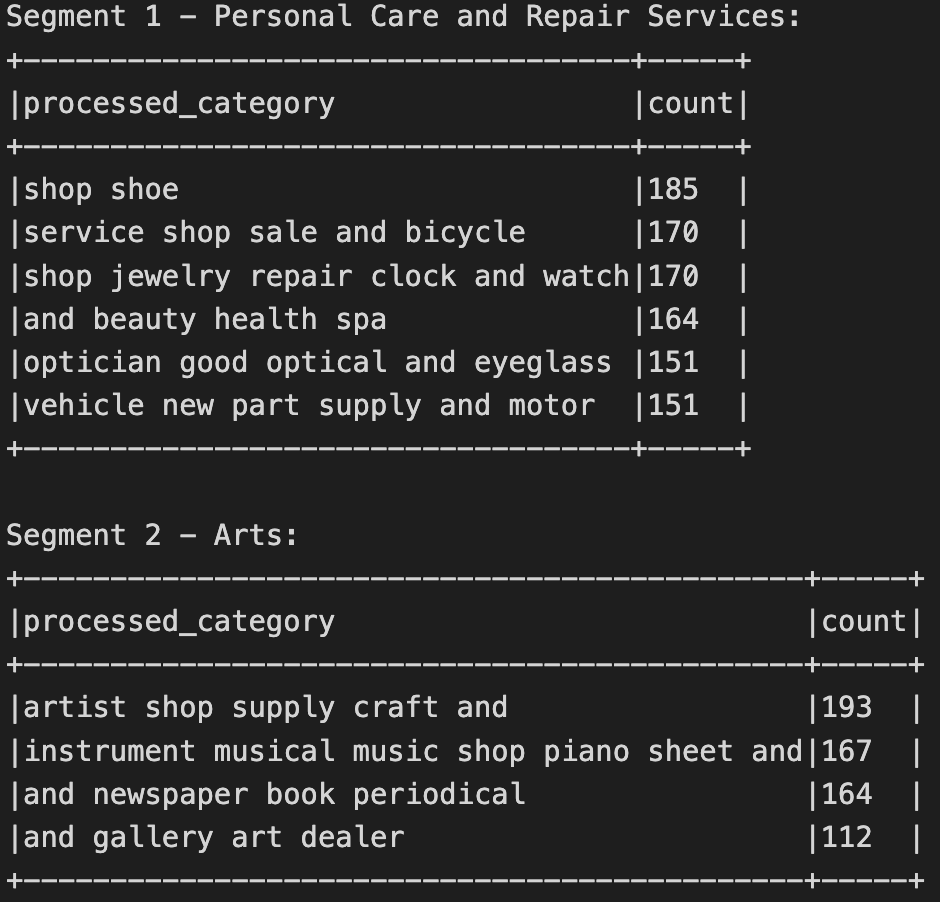

In [29]:
Image(filename='../plots/classificaiton_1.png', width=500, height=600)

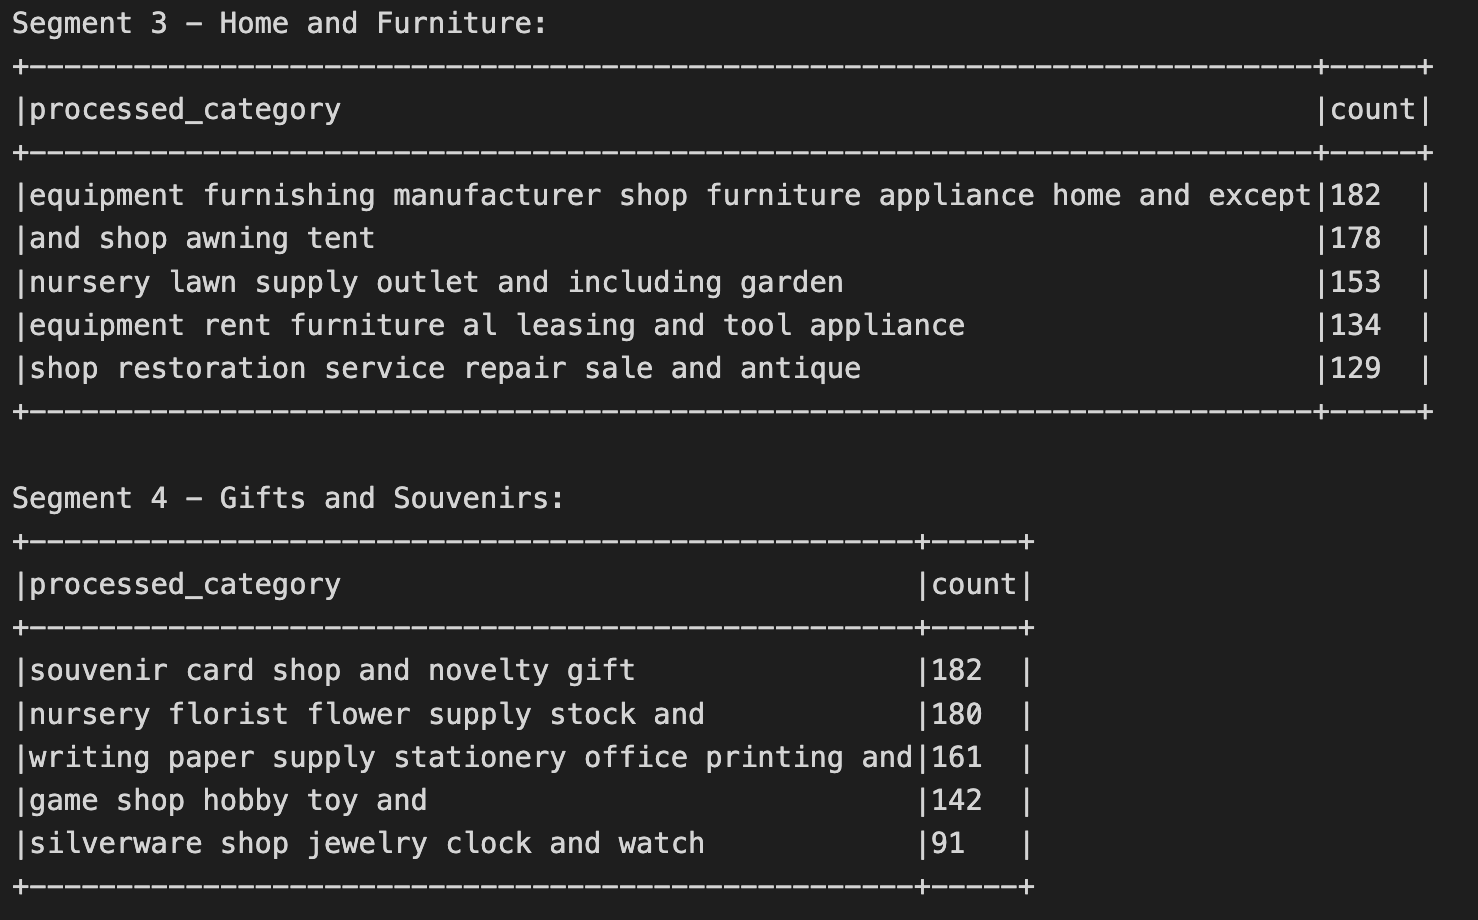

In [32]:
Image(filename='../plots/classificaiton_2.png', width=700, height=900)

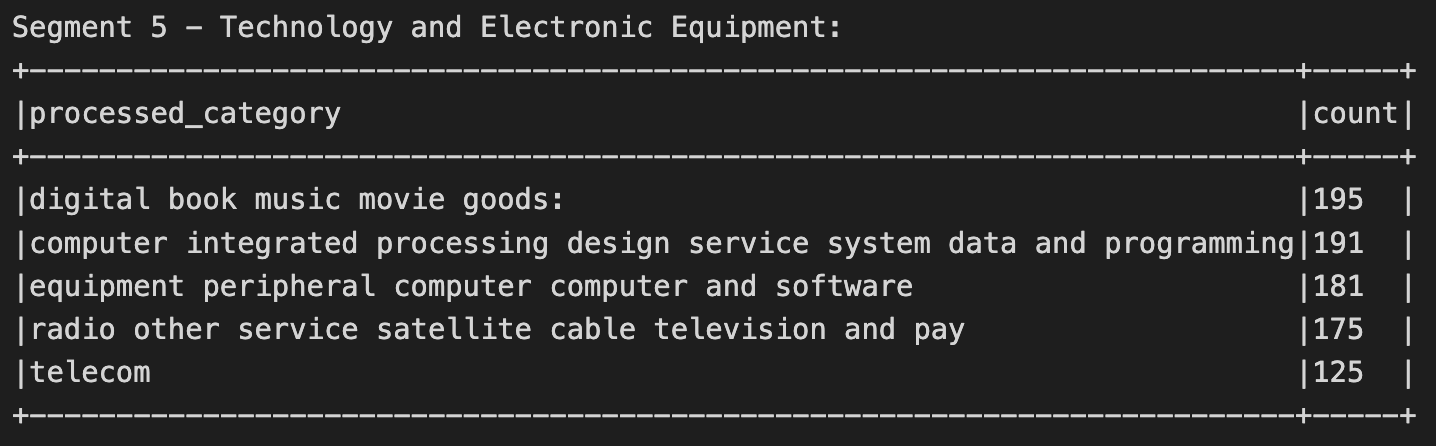

In [34]:
Image(filename='../plots/classificaiton_3.png', width=700, height=900)

The following is the full transaction table include the feature which indicates the classification of merchants.

In [ ]:
full_transaction_with_segments = spark.read.parquet('../data/curated/full_transaction_with_segments')
full_transaction_with_segments.show(5, truncate=False)

+------------+------------------------------------+---------+--------------------------+-------------------+-------------------+---------------+---------------+---------------+---------------+---------------+----------------+------------+-------------------+--------------+--------------+---------------+--------------+---------------+---------------+-----------------+---------------+----------------+----------------+-------------------+------------+----------------+------------------+-------------+-------------+---------------+---------------+-------------+--------------+--------------------+--------------+-------------------+-----------------+--------------+-----------------+--------------+-------------------+--------------+---------------+---------------+-------------+--------------+-------------------+--------------+--------------+----------------+-------------+-------------+---------------+---------------+----------------+----------------+---------------+------------------+---------

## 7. Interesting Findings

We found the merchants with small customer bases but large transaction values are more prone to fraud.

The following plot shows the merchants with less than 200 customers and average purchase value is greater than $5000.

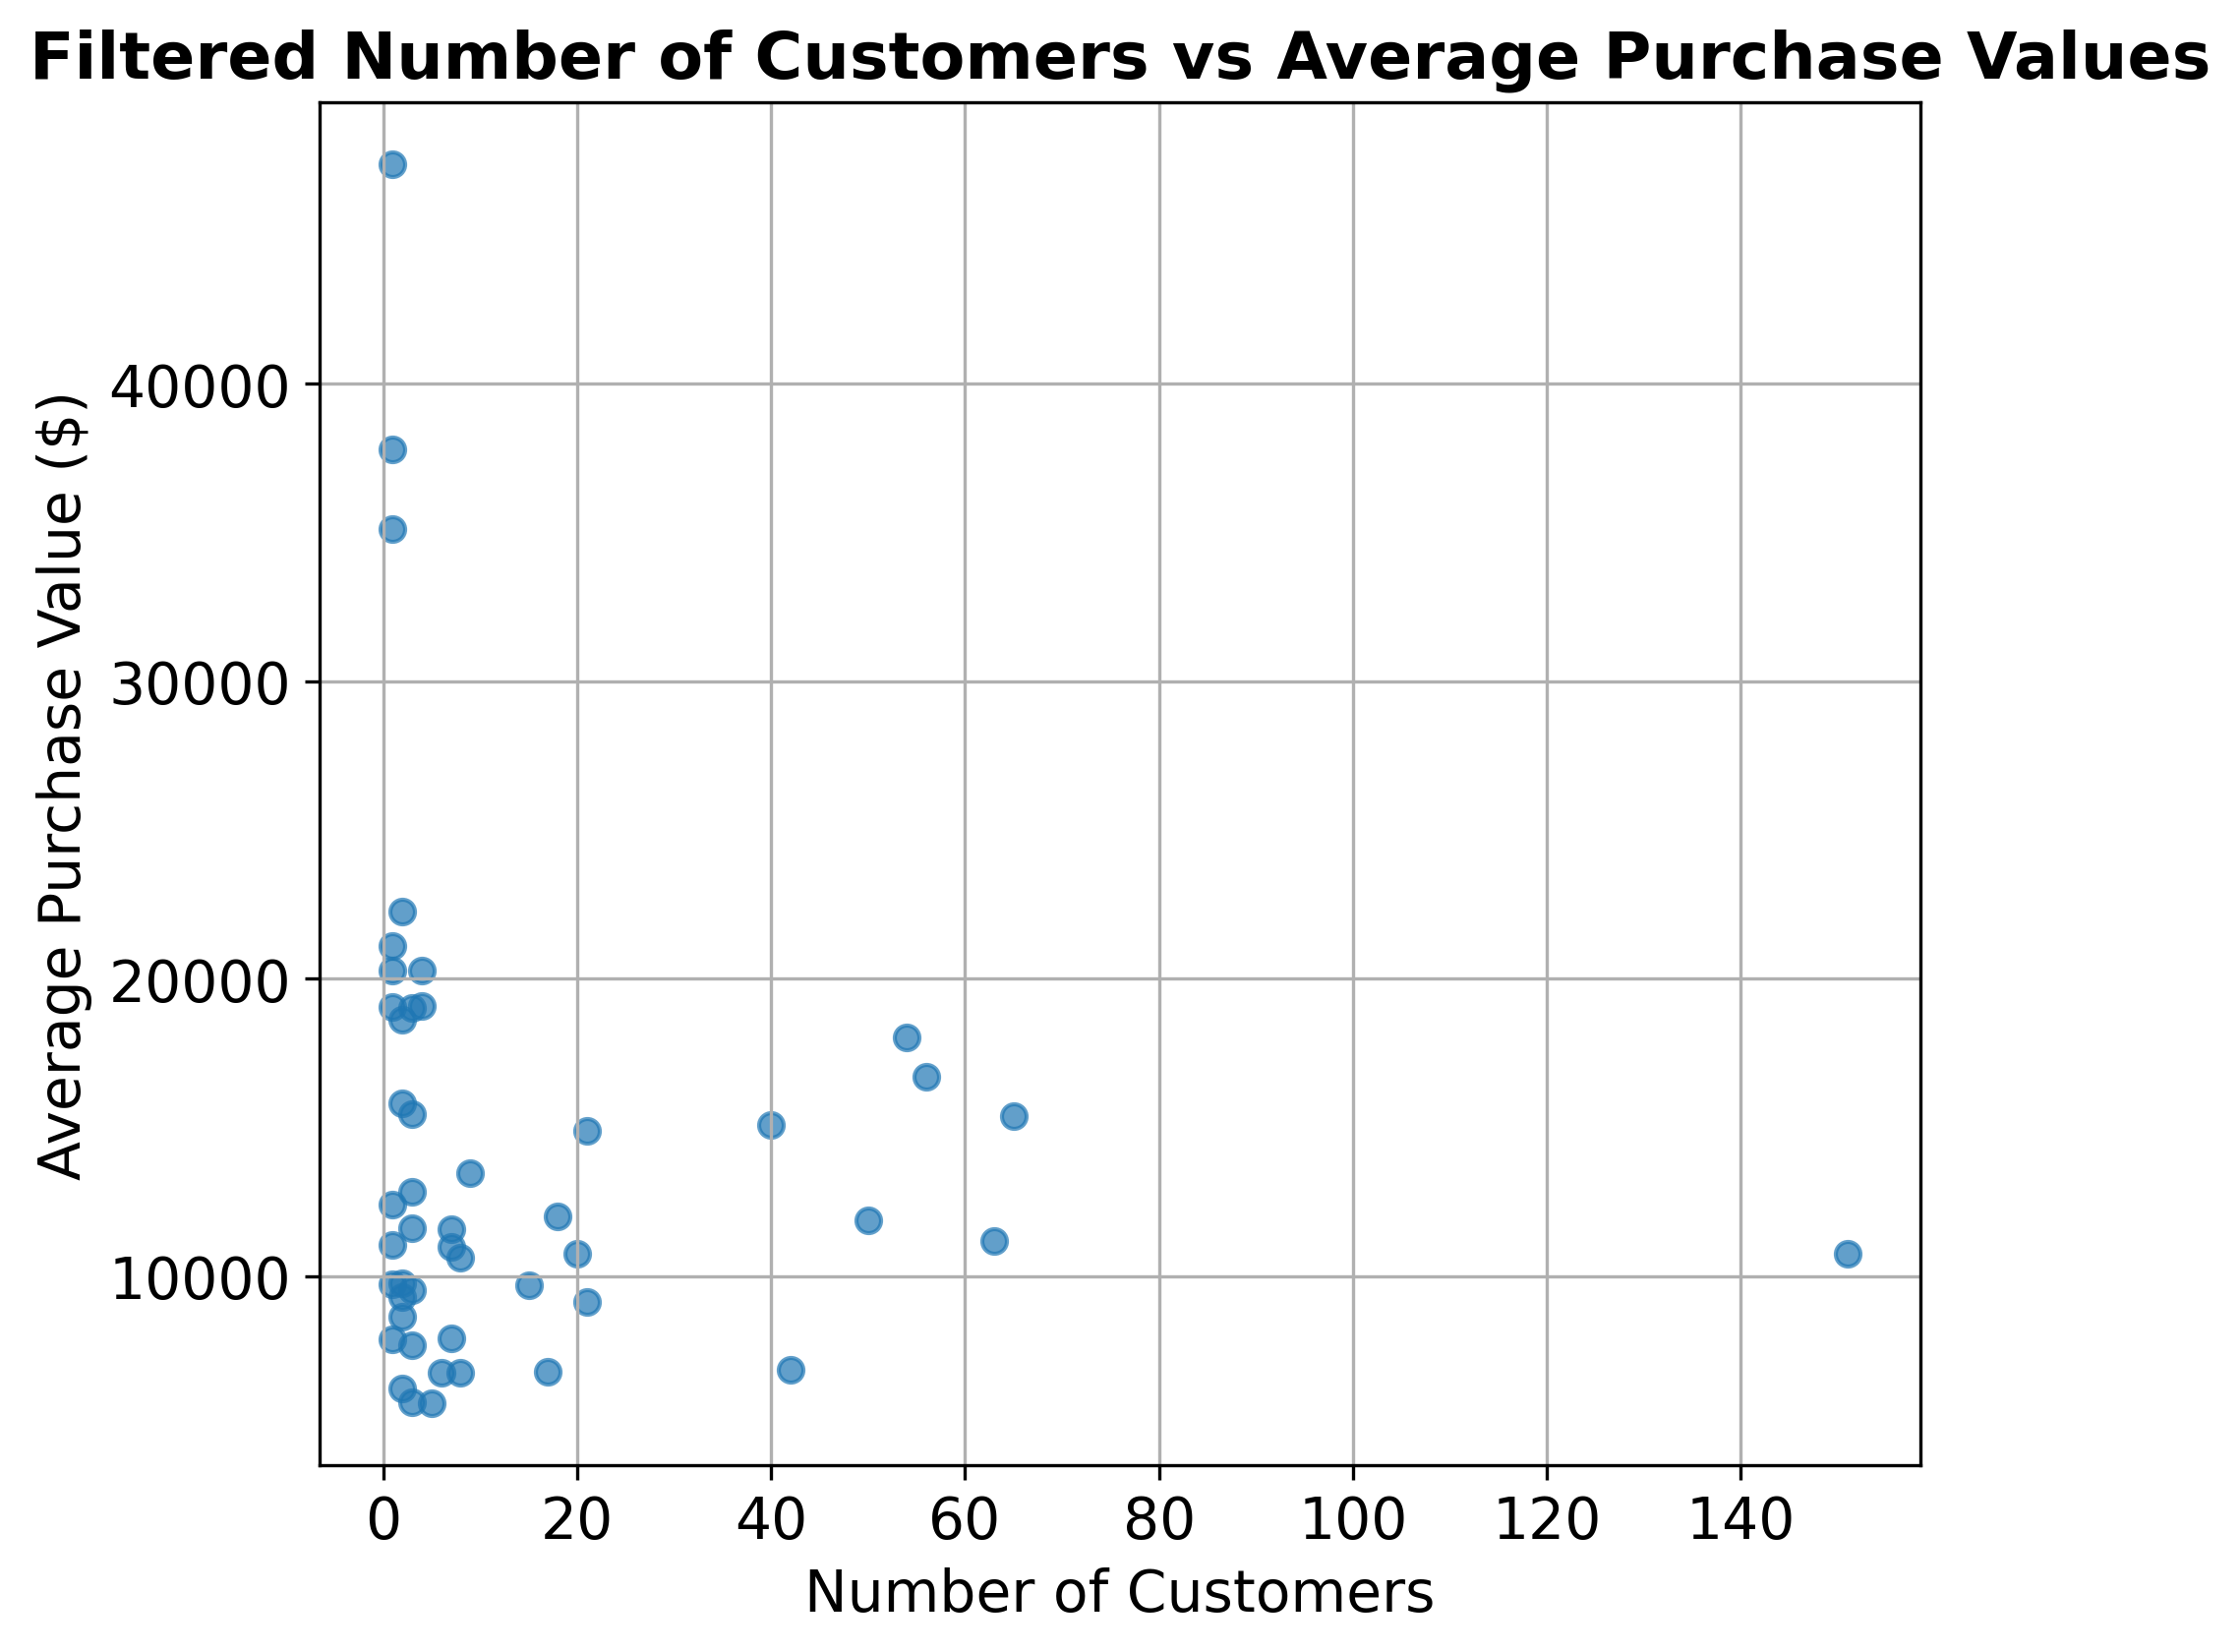

In [35]:
Image(filename='../plots/filtered_num_customer_vs_avg_dollar_value.png',
       width=700, height=900)

The following plot shows most merchant fraud probability is above 50%, some reach 80-90%.

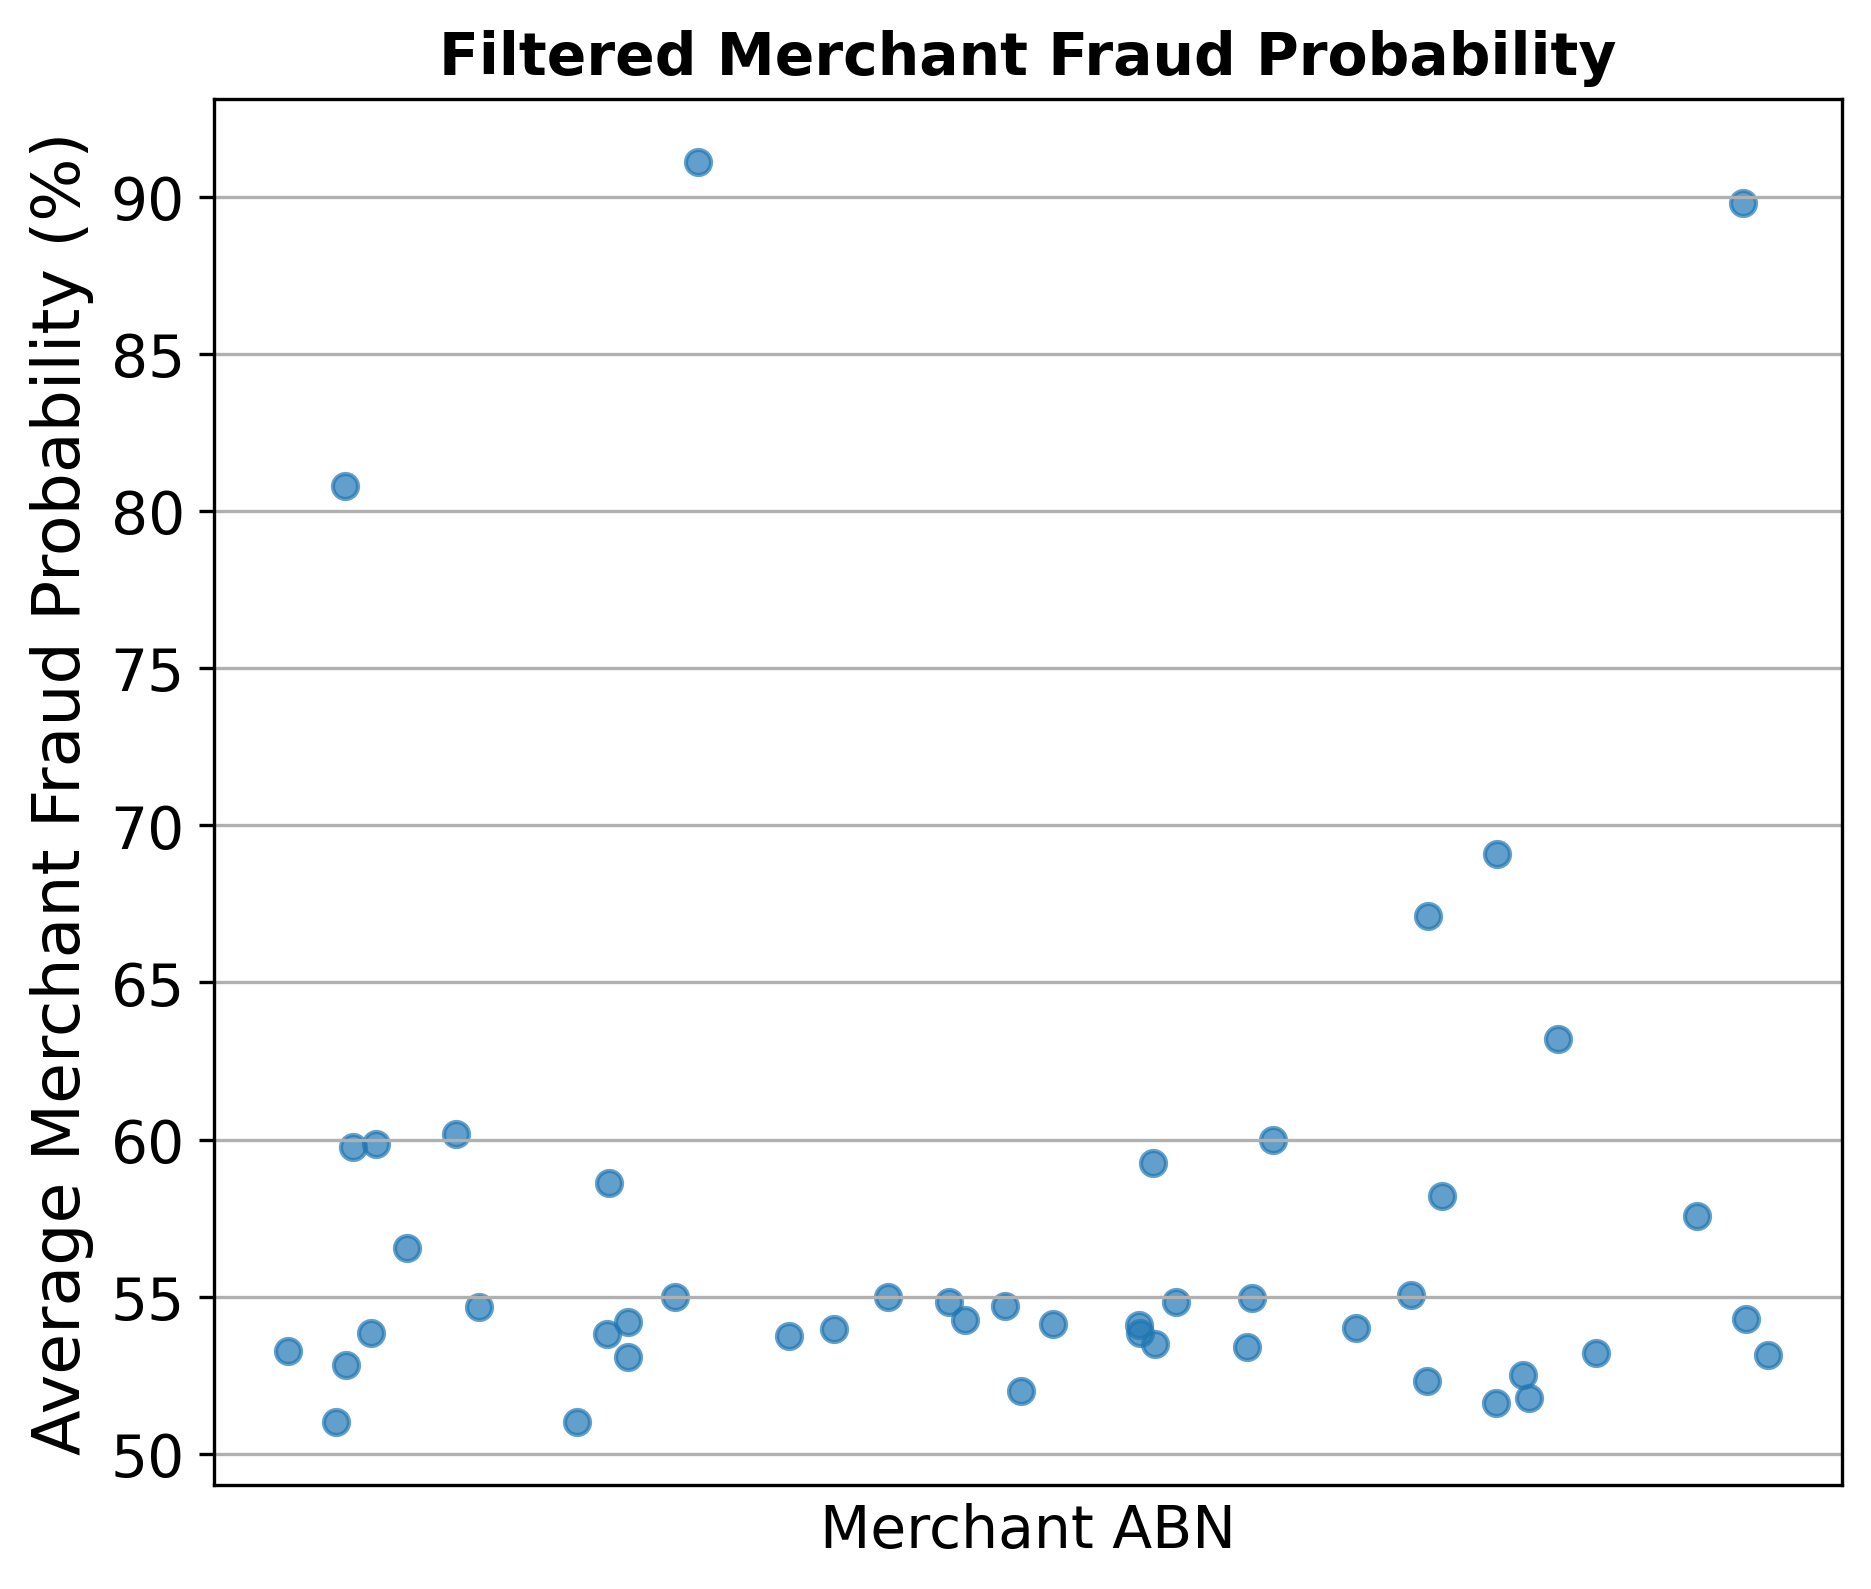

In [40]:
Image(filename='../plots/filtered_abn_vs_avg_merchant_fraud_prob.png',
       width=600, height=800)

The following plot shows most consumer fraud probability is around 10-30%, some of them are greater than 50%.

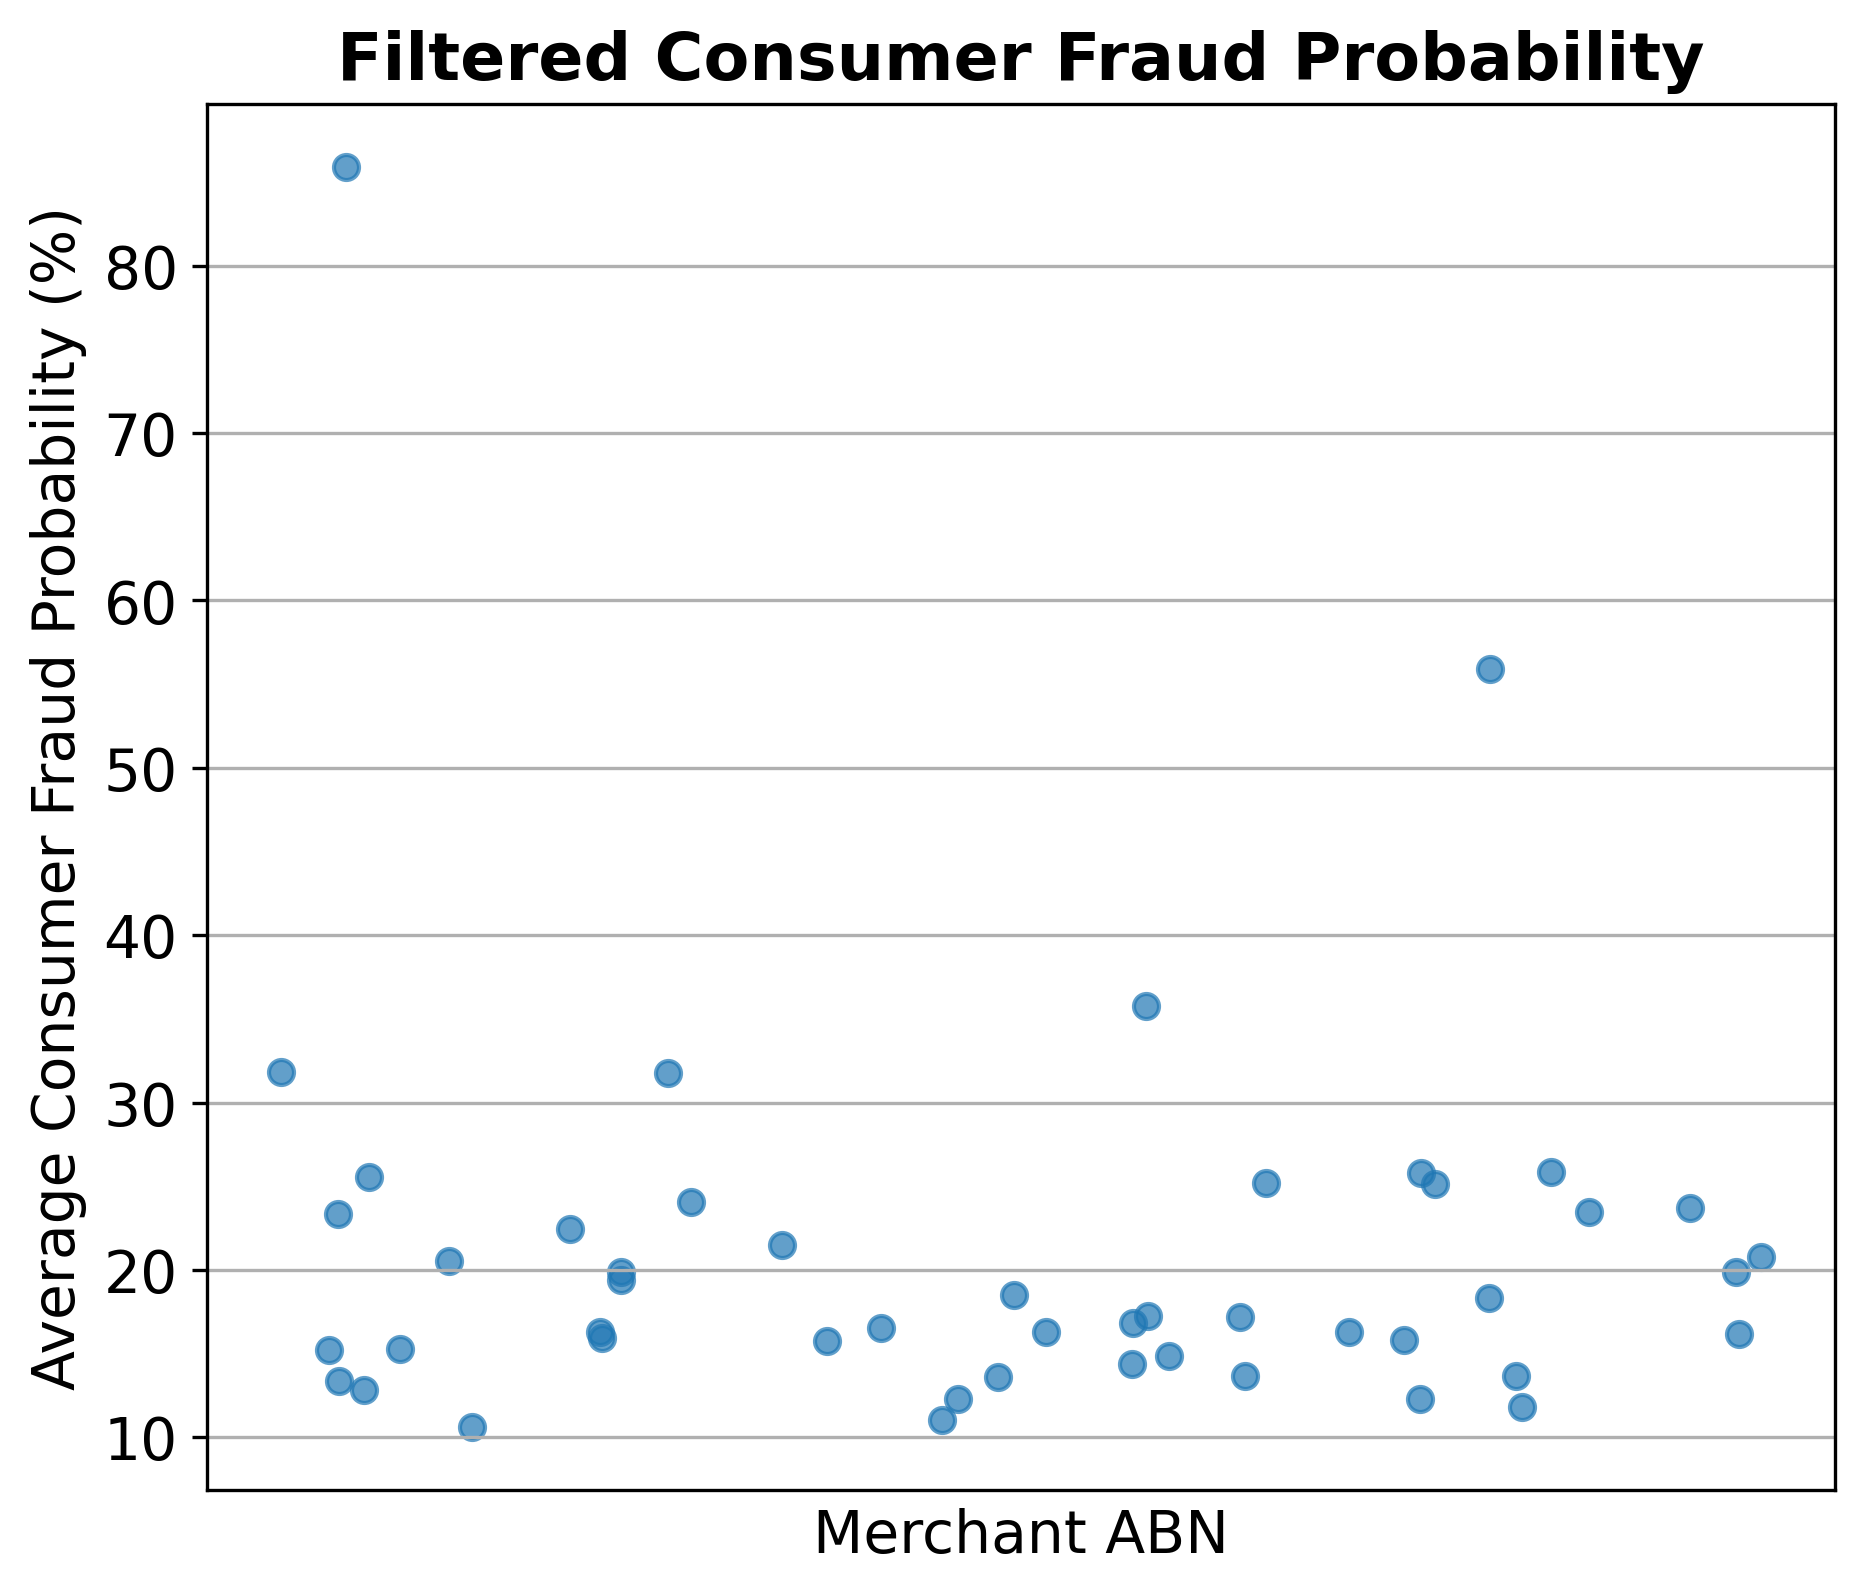

In [42]:
Image(filename='../plots/filtered_abn_vs_avg_consumer_fraud_prob.png',
       width=600, height=700)

## 8. Modelling

### Summary of Models:

The following picture shows the summary of models we used in this project.

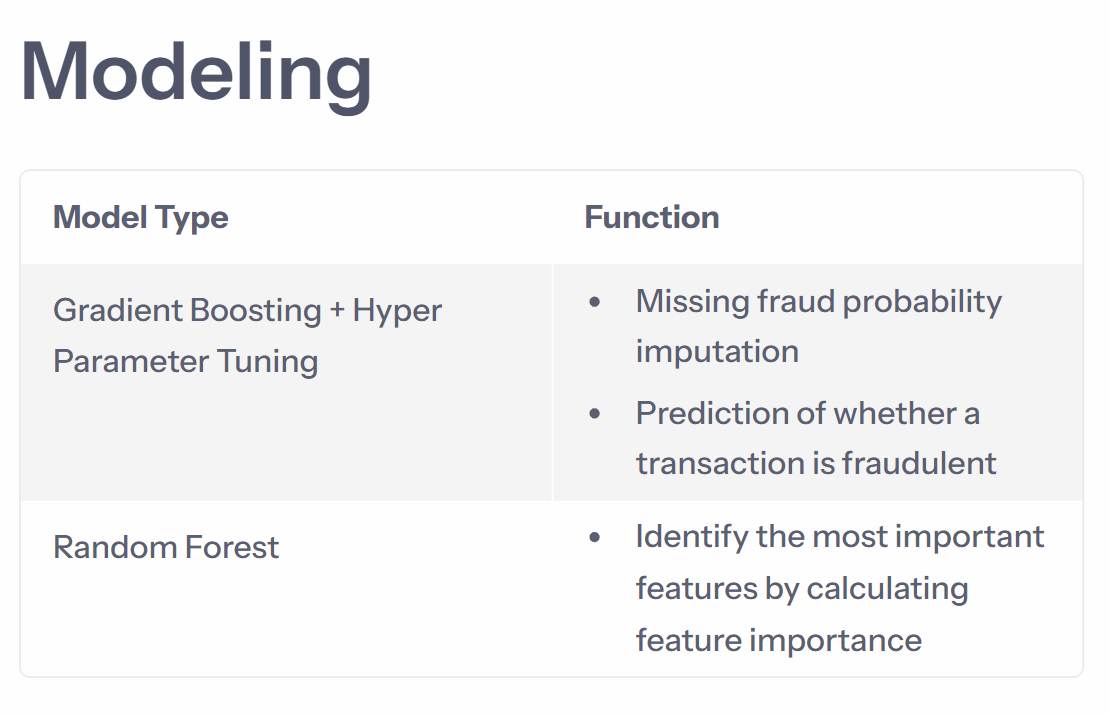

In [50]:
Image(filename='../plots/modelling_summary.jpg', width=600, height=900)

### Prediction of Fradulent Transactions:

We used Gradient Boosting as the model to predict transaction fraud in the future.

The following screenshots show the evaluation of Gradient Boosted Trees.

The ROC AUC Score (Receiver Operating Characteristic Area Under the Curve) is a metric used to evaluate the performance of binary classification models. It quantifies a model's ability to distinguish between two classes, with a score ranging from 0 to 1. 
- A score of 1 indicates perfect classification
- A score of 0.5 equates to no better than random guessing
- A score of 0 implies complete misclassification.

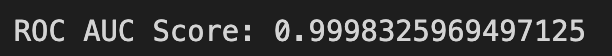

In [54]:
Image(filename='../plots/evaluation_1.png', width=400, height=600)

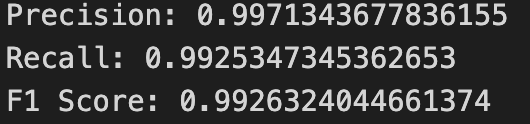

In [53]:
Image(filename='../plots/evaluation_2.png', width=400, height=600)

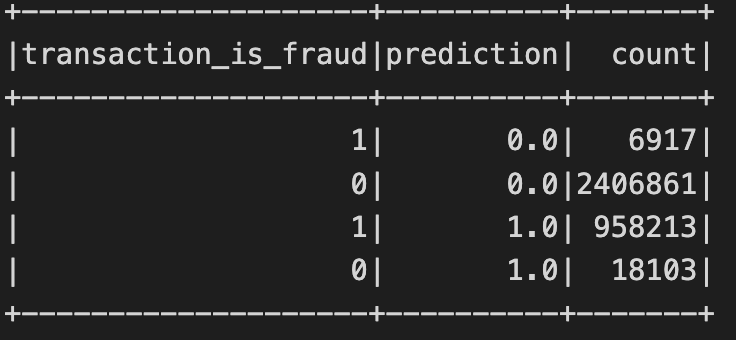

In [52]:
Image(filename='../plots/evaluation_3.png', width=400, height=600)

## 9. Ranking

Our ranking system use feature importances calculated by random forest model as weights to calculate the weighted ranking score for each merchant. Then selected the top merchants.

### Overall Top 100 Merchants:

The following screenshot shows the selected merchant ABN.

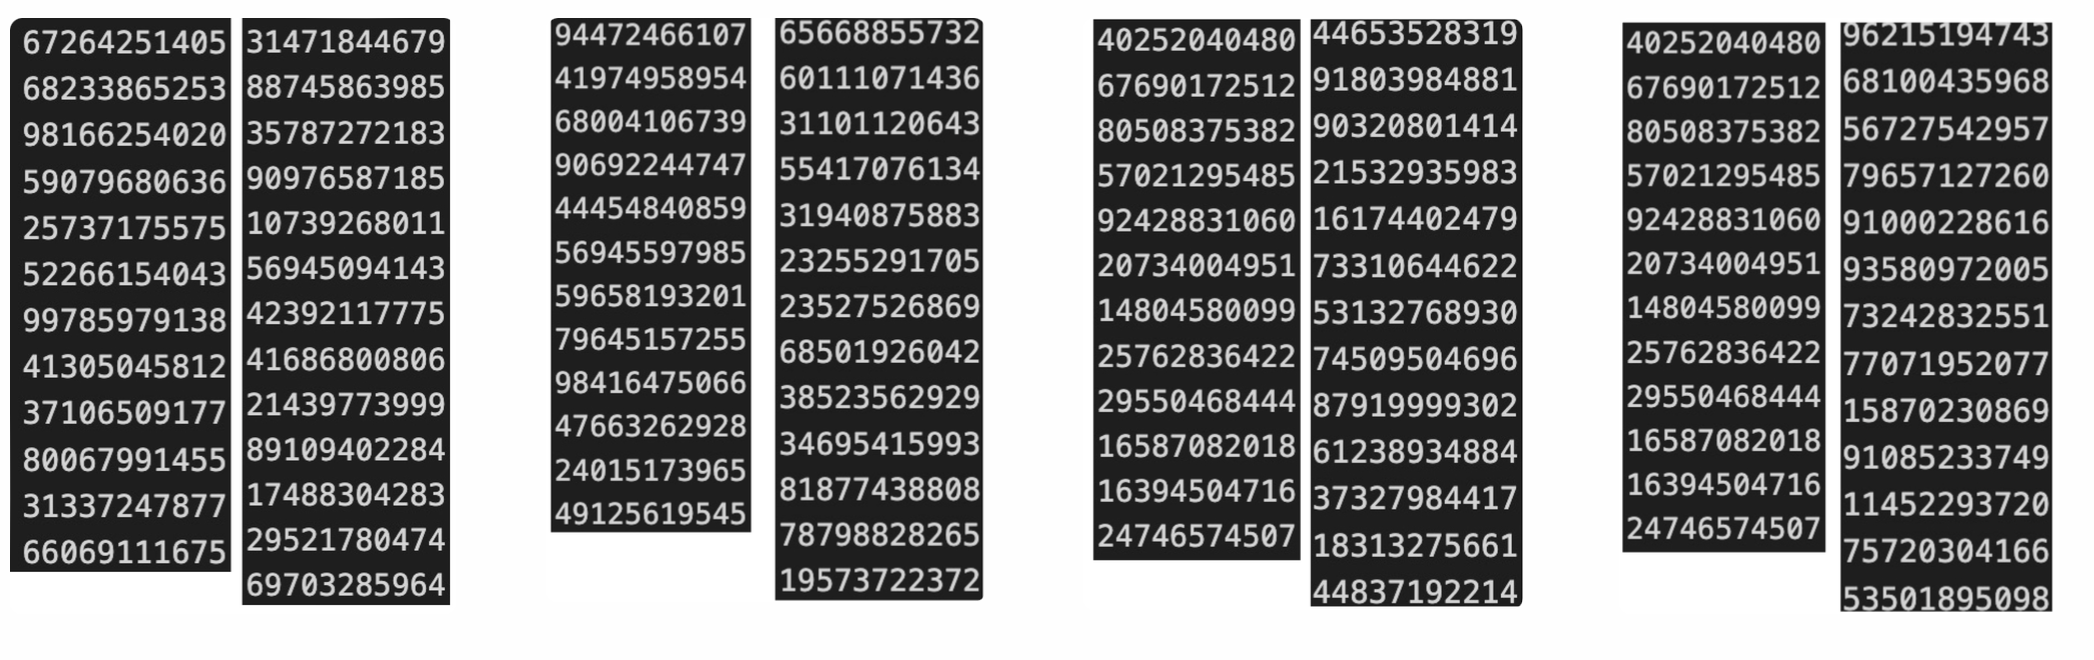

In [61]:
Image(filename='../plots/overall_top100_merchants.png', width=900, height=1000)

The following screenshot shows the number of selected merchants in each segment.

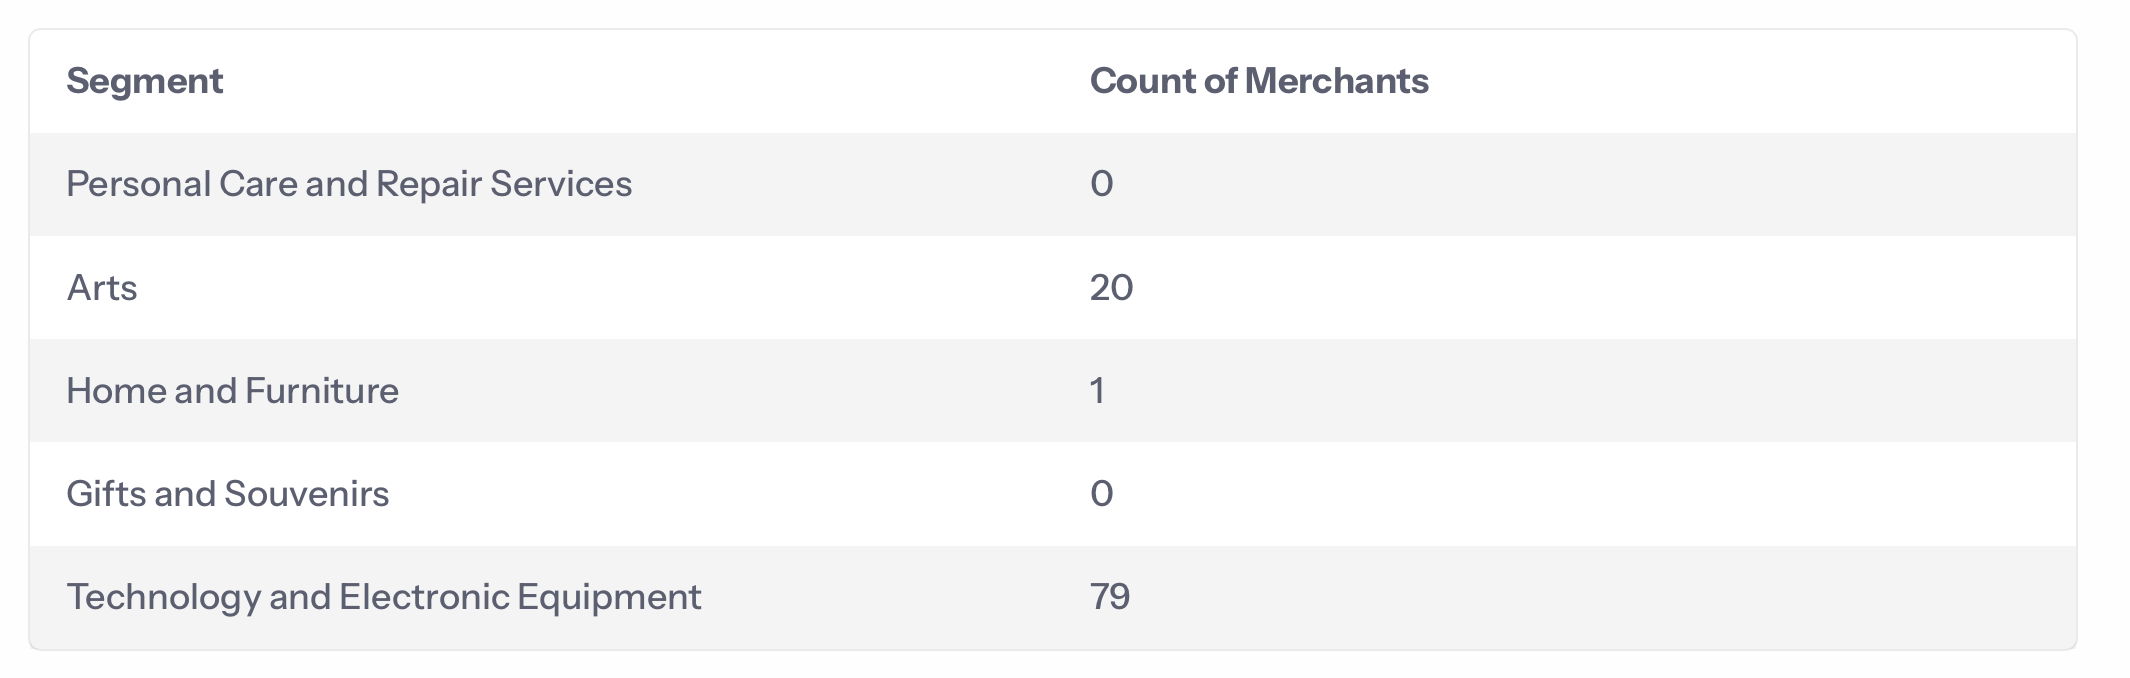

In [64]:
Image(filename='../plots/selected_merchant_category_count.png', width=900, height=1000)

### Top 10 Merchants for Each Segment:

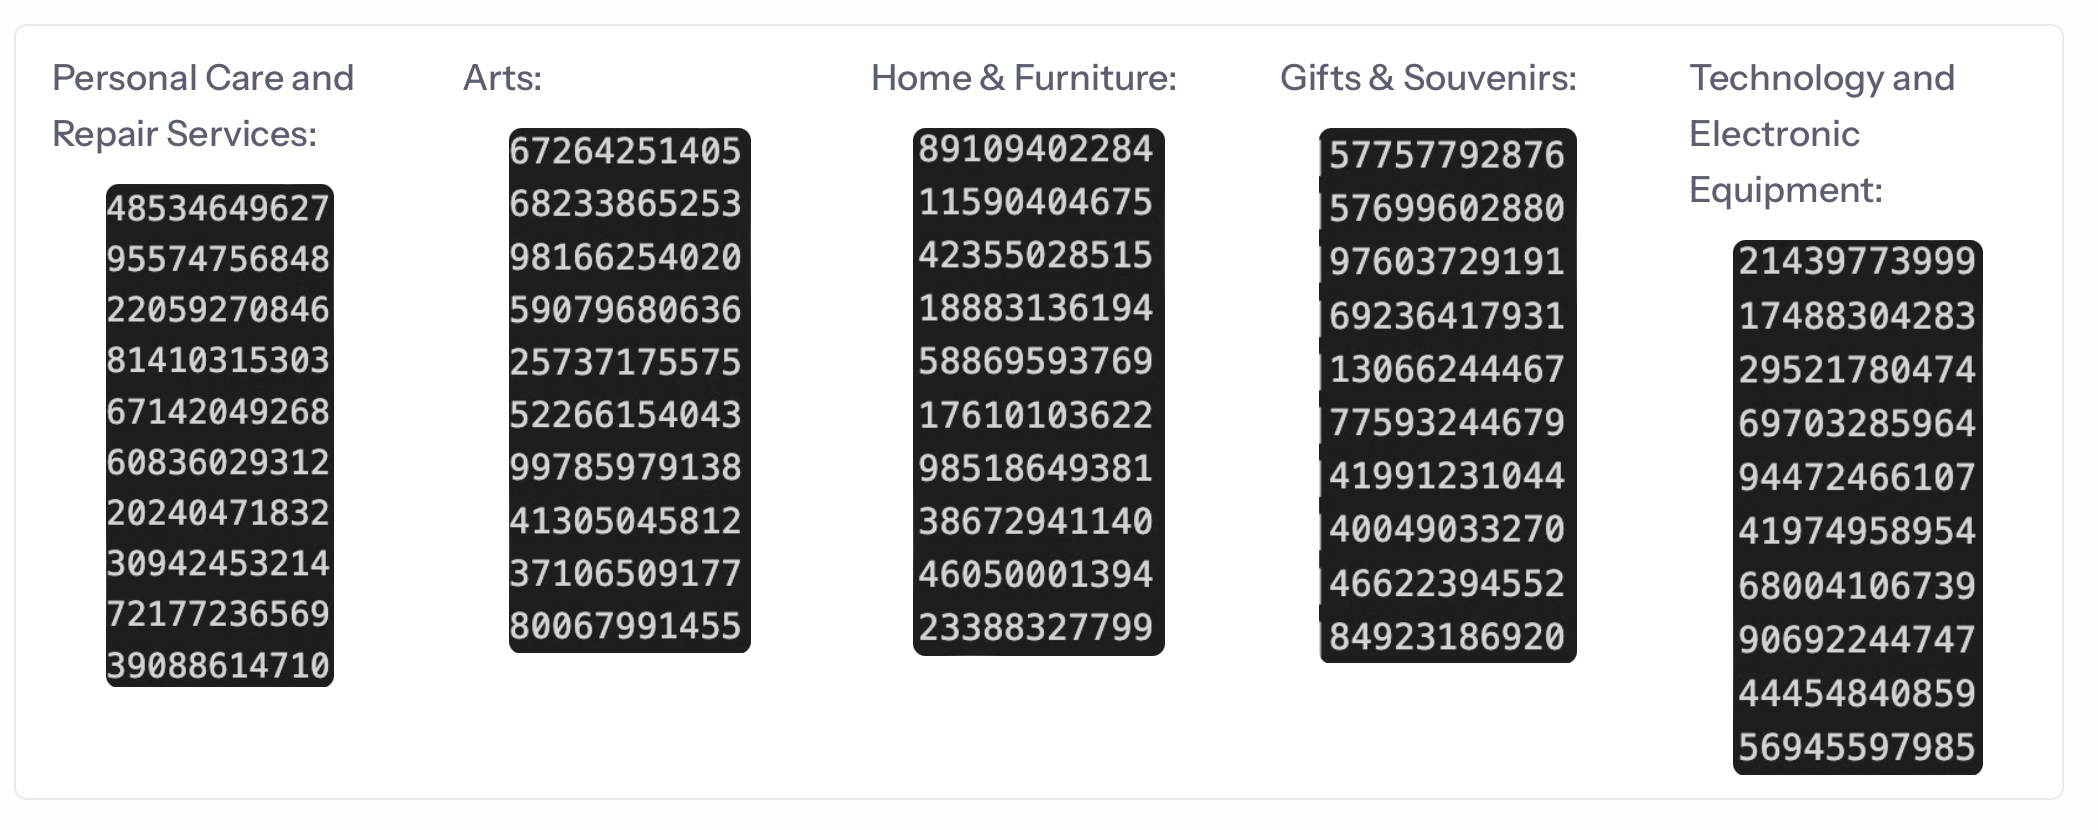

In [63]:
Image(filename='../plots/top10_merchants_in_each_segment.png', width=900, height=1000)

## 10. Visualization

The following screenshot shows the comparison between the distributions before and after missing consumer fraud probability imputation.

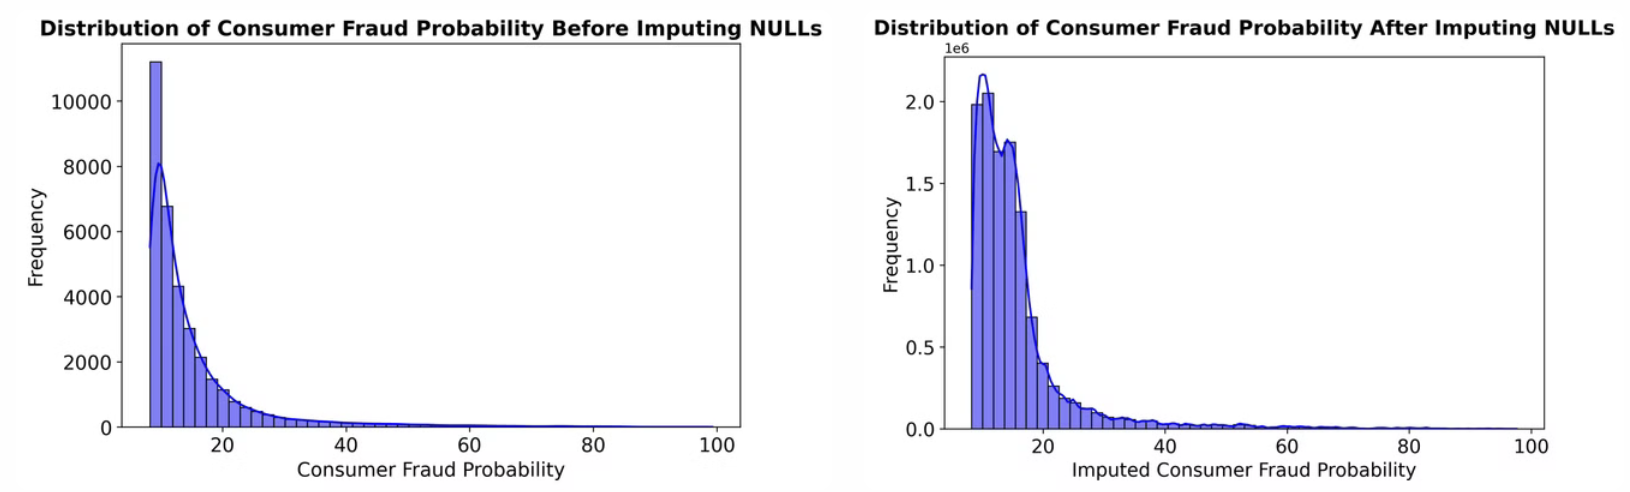

In [65]:
Image(filename='../plots/consumer_imputation_compare.png', width=900, height=1000)

The following screenshot shows the comparison between the distributions before and after missing merchant fraud probability imputation.

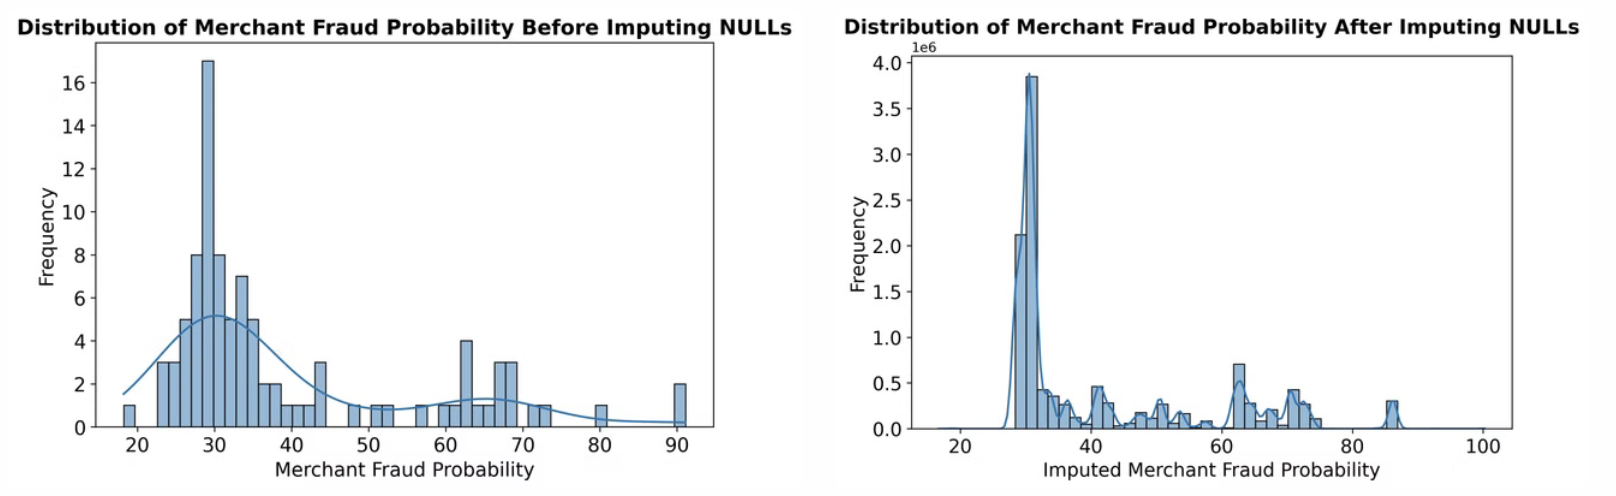

In [66]:
Image(filename='../plots/merchant_imputation_compare.png', width=900, height=1000)

We also visualized the features by drawing different figures, following are the examples.

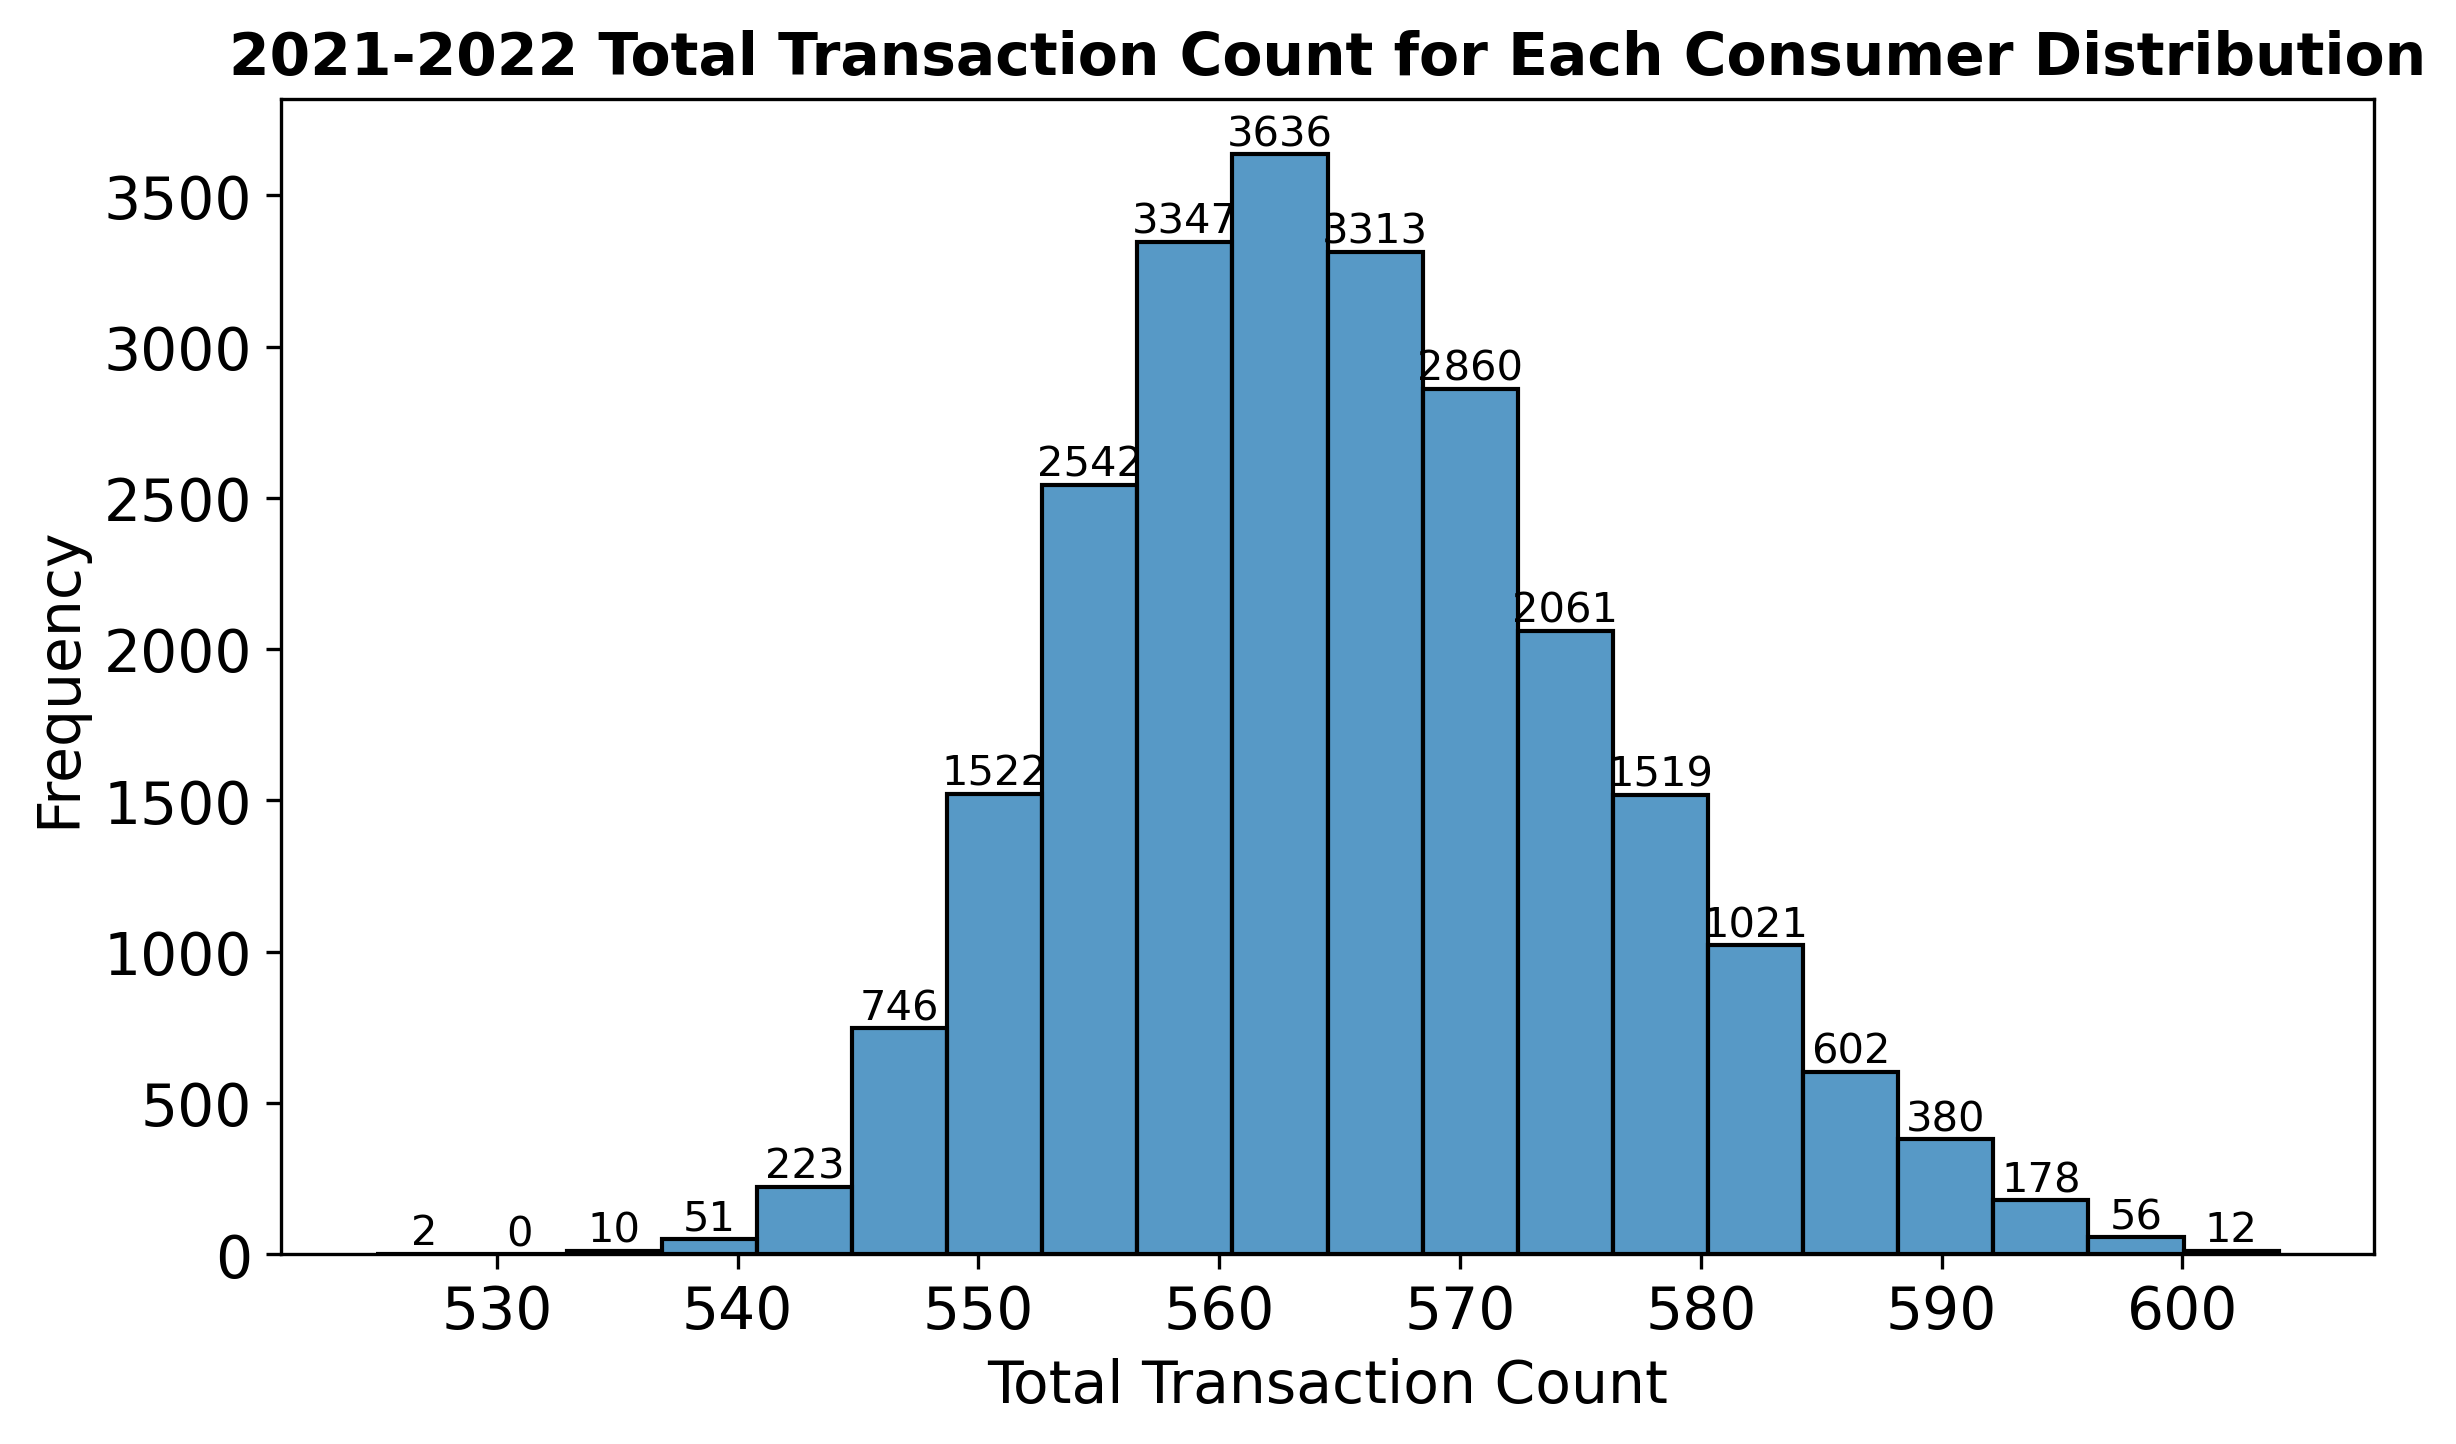

In [73]:
Image(filename='../plots/consumer_total_count_hist.png', width=900, height=1000)

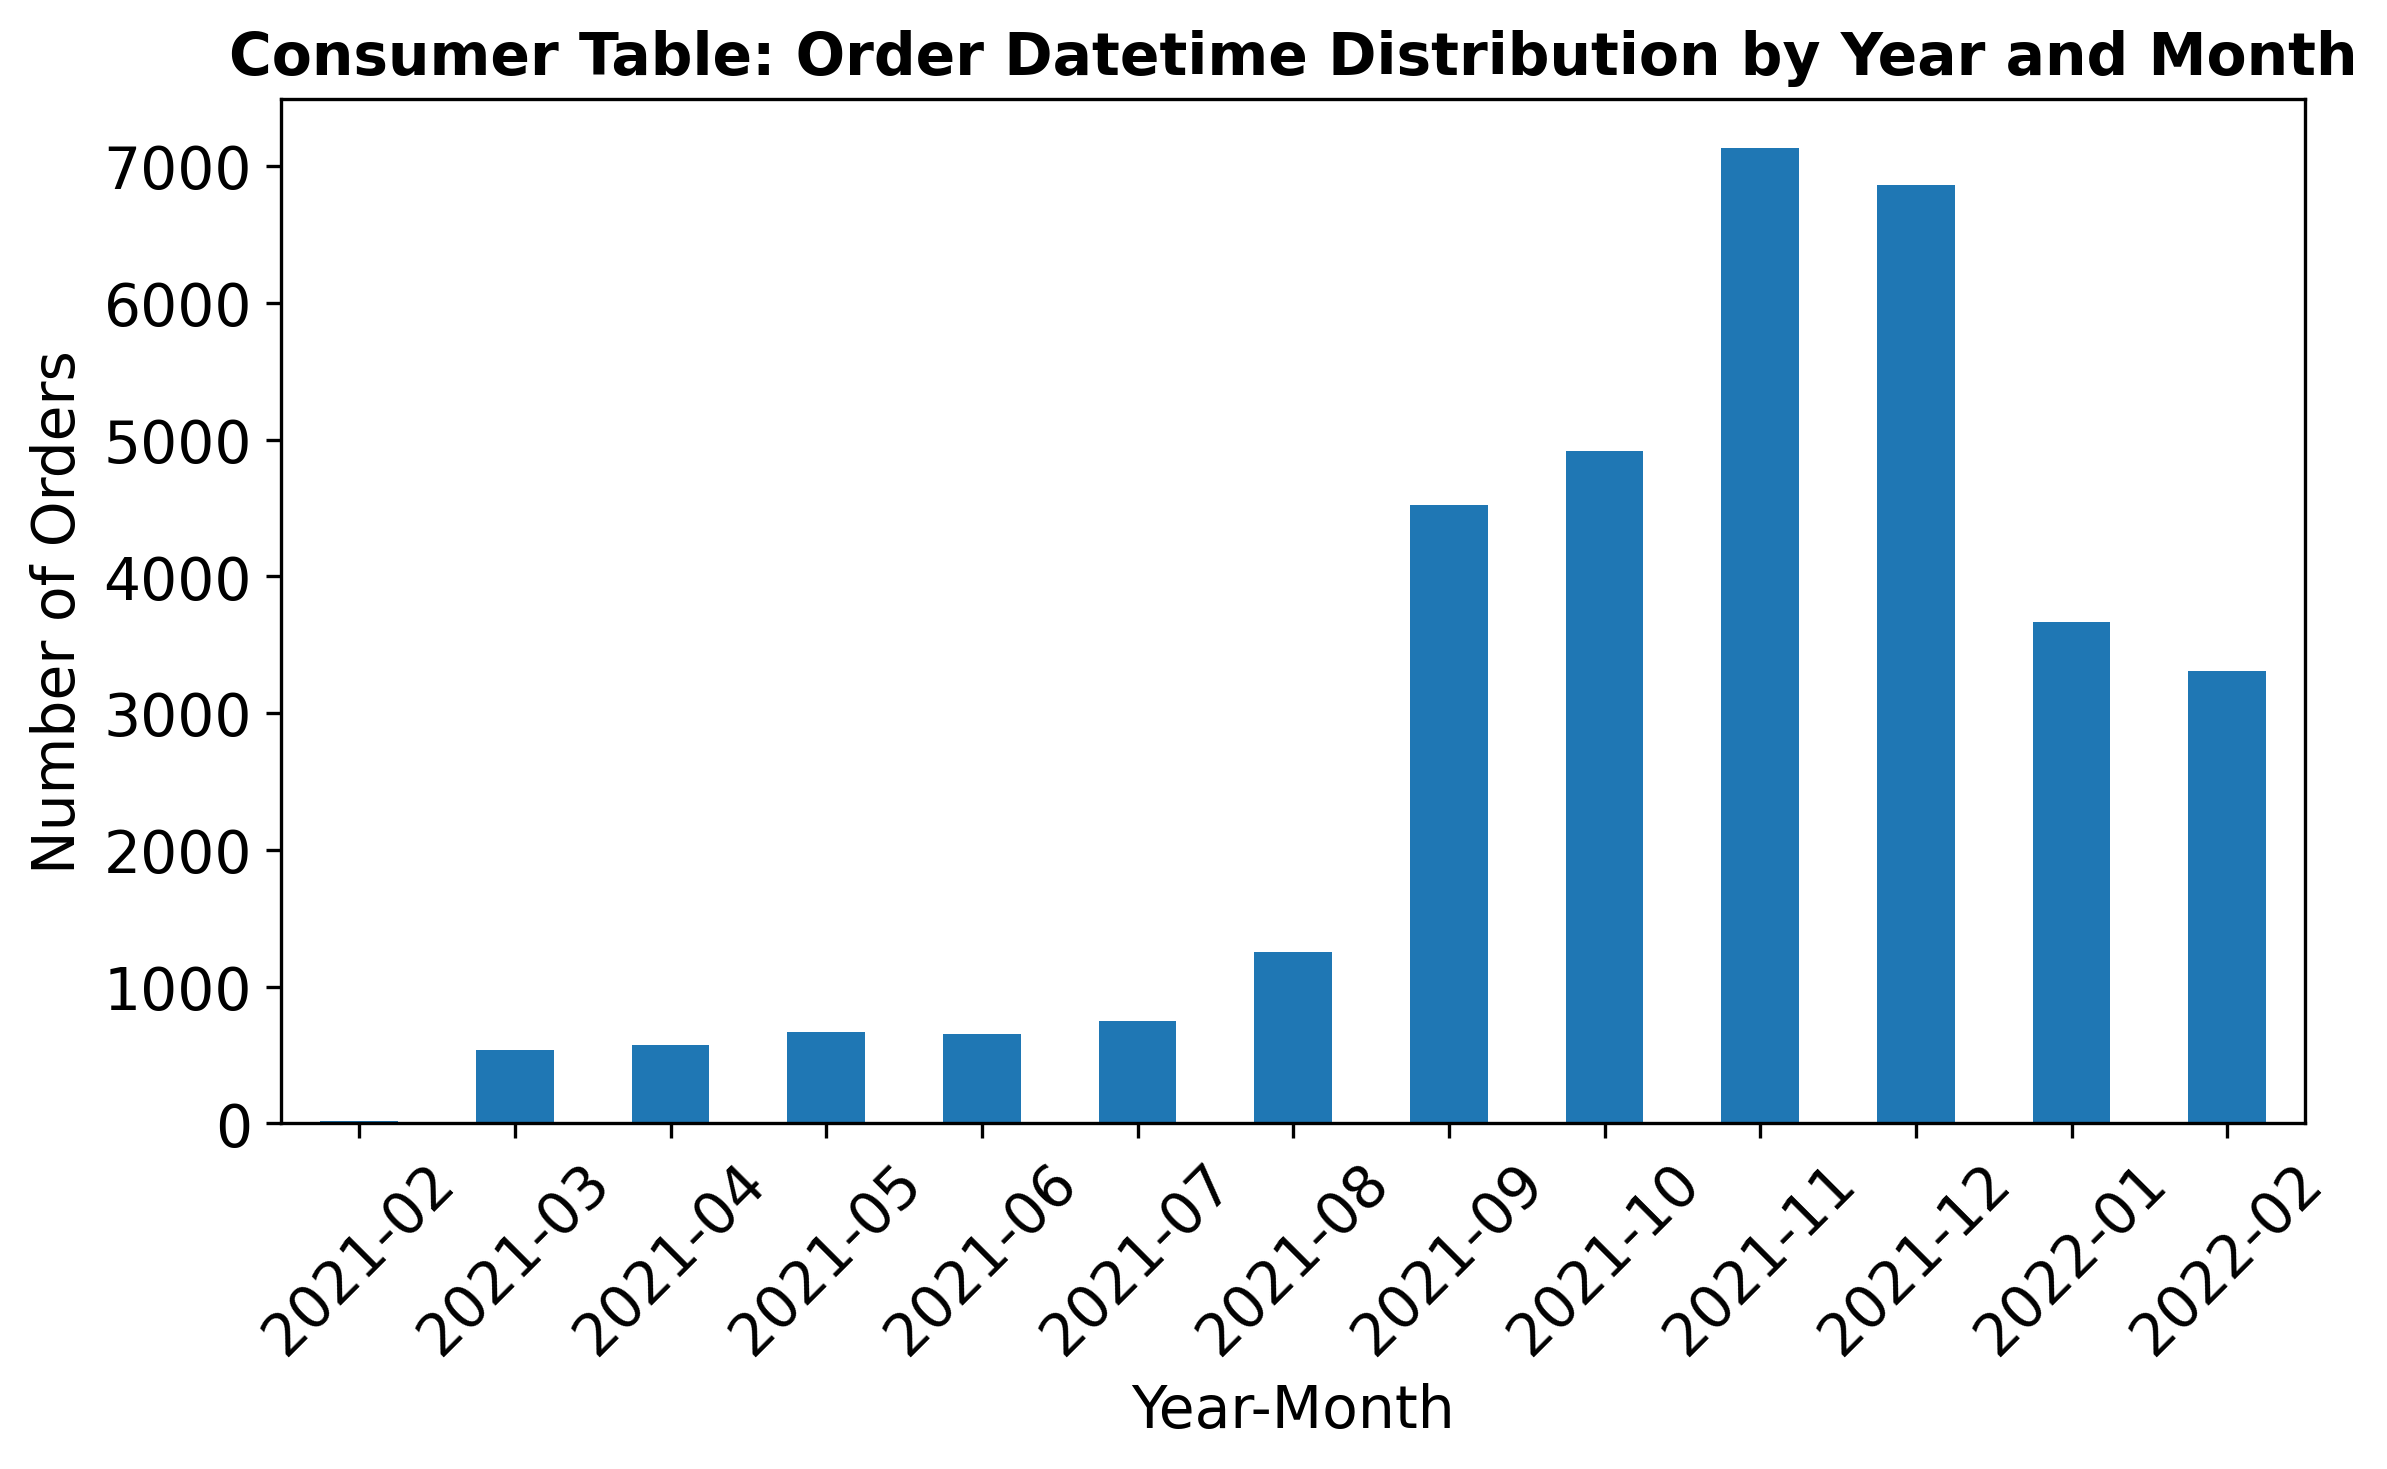

In [68]:
Image(filename='../plots/consumer_orderdate_by_year_month.png', width=900, height=1000)

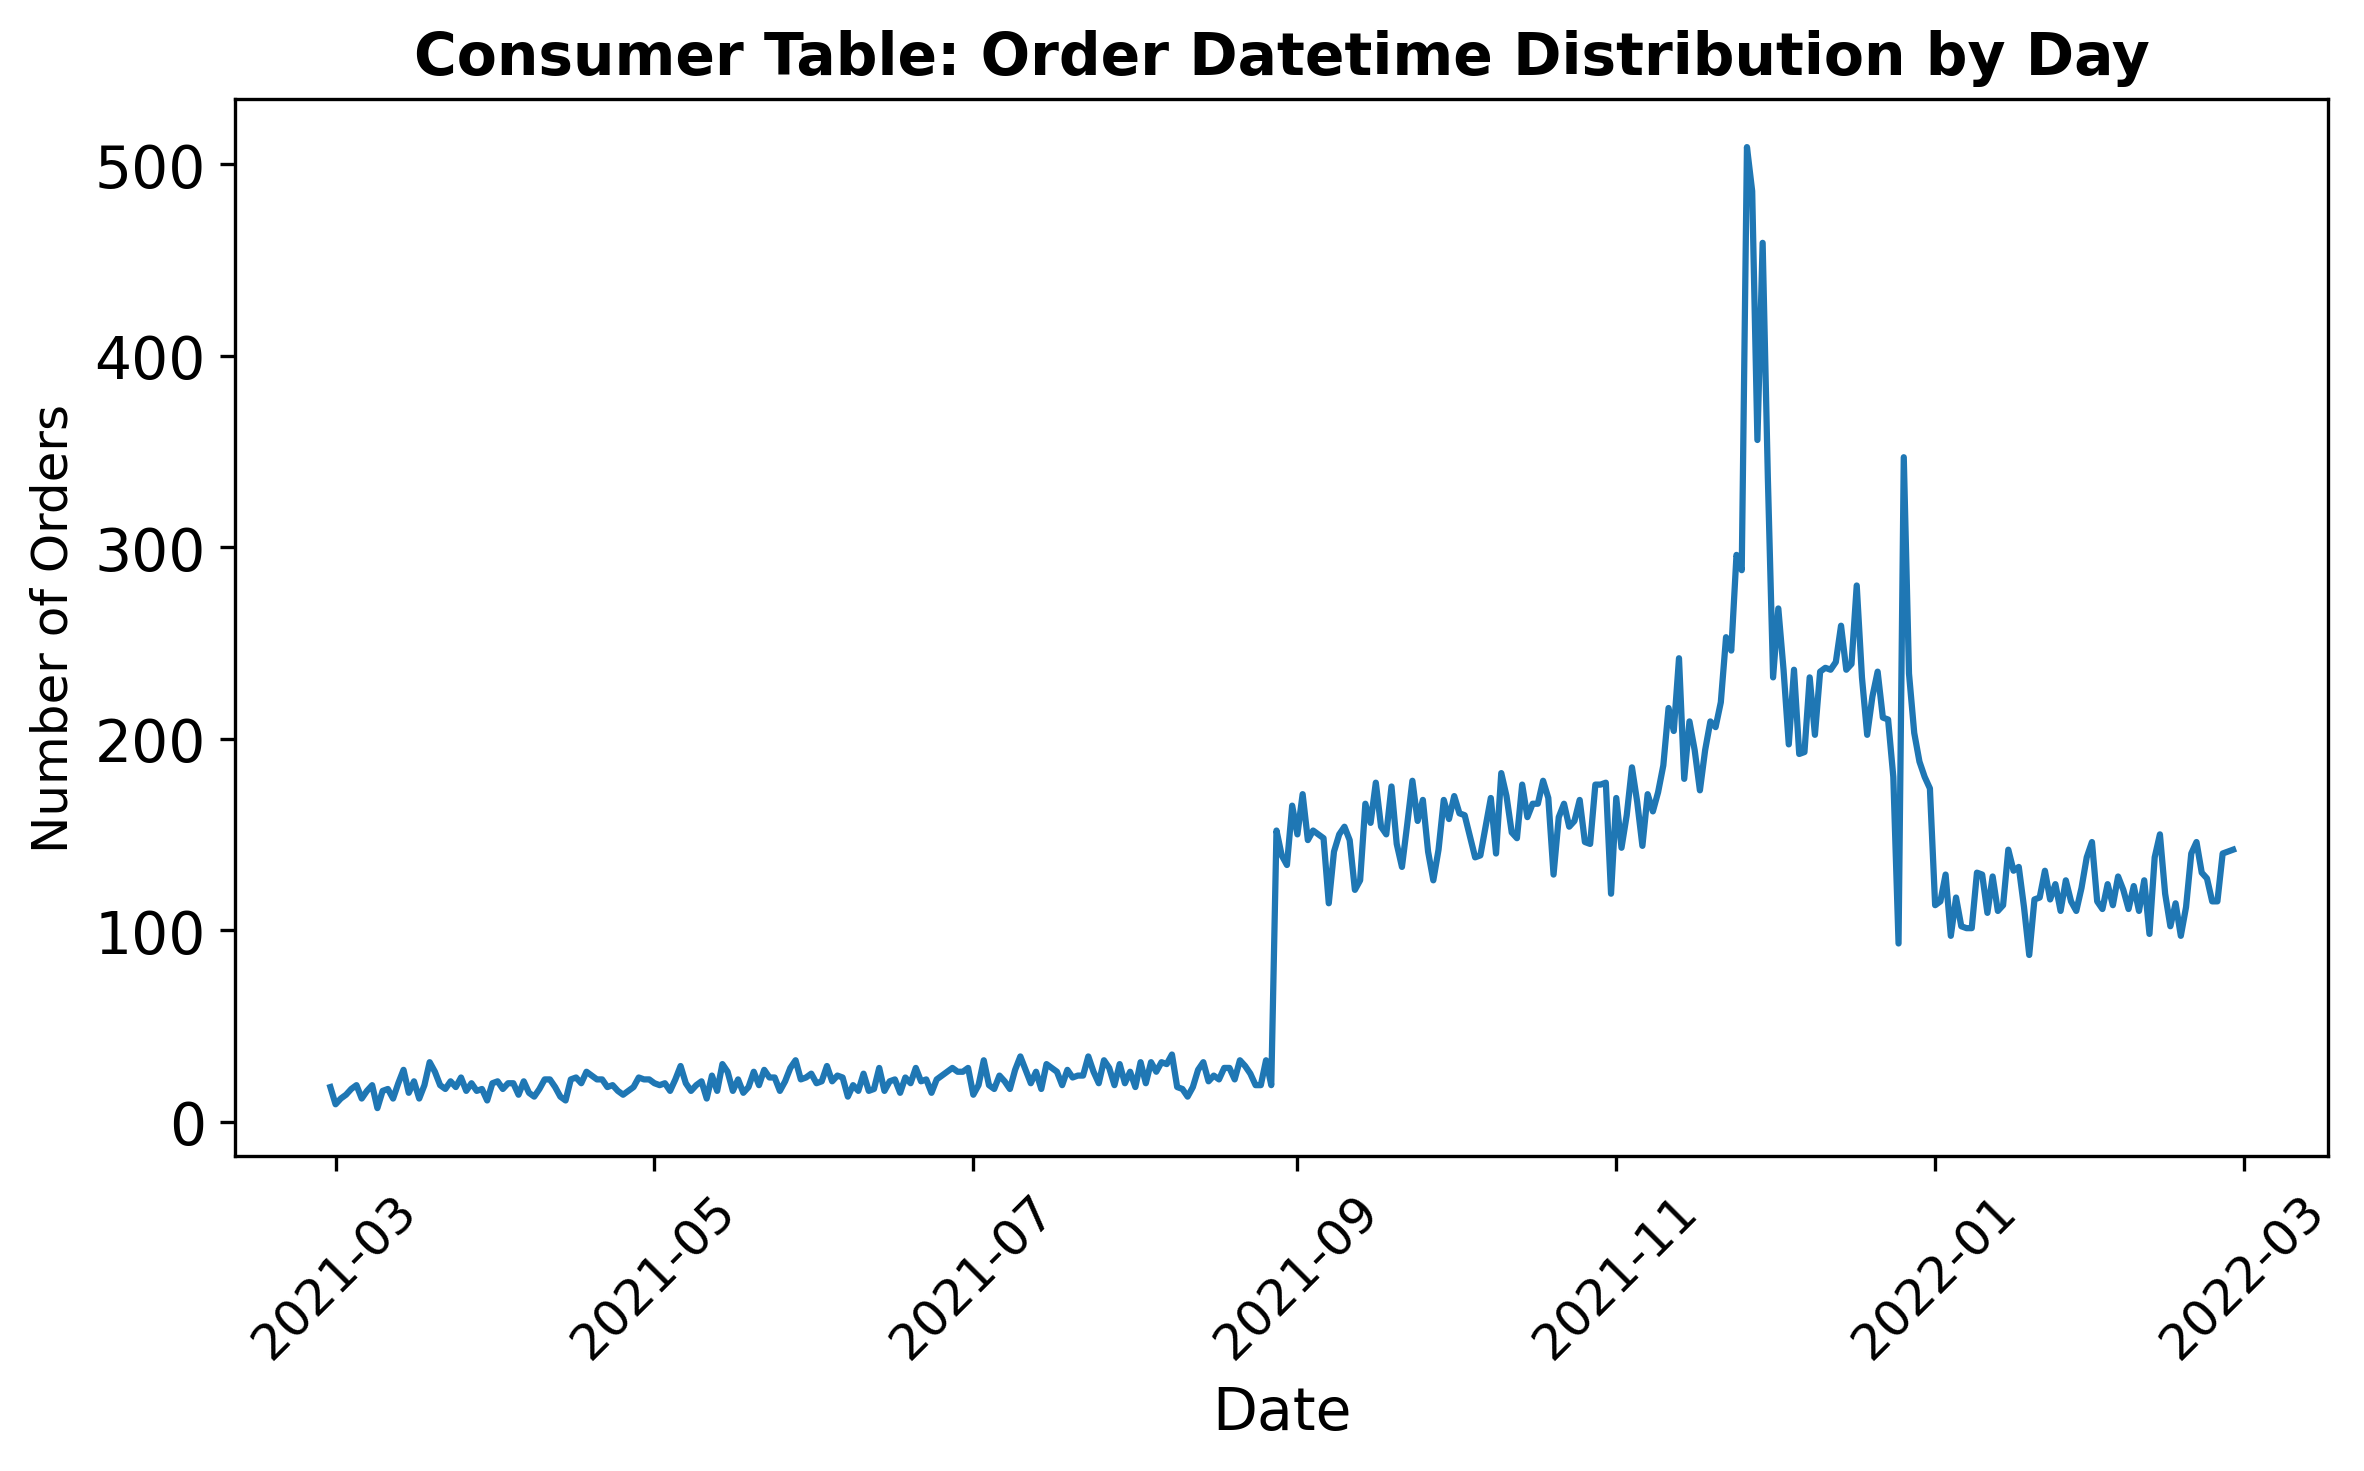

In [69]:
Image(filename='../plots/consumer_orderdate_by_day.png', width=900, height=1000)

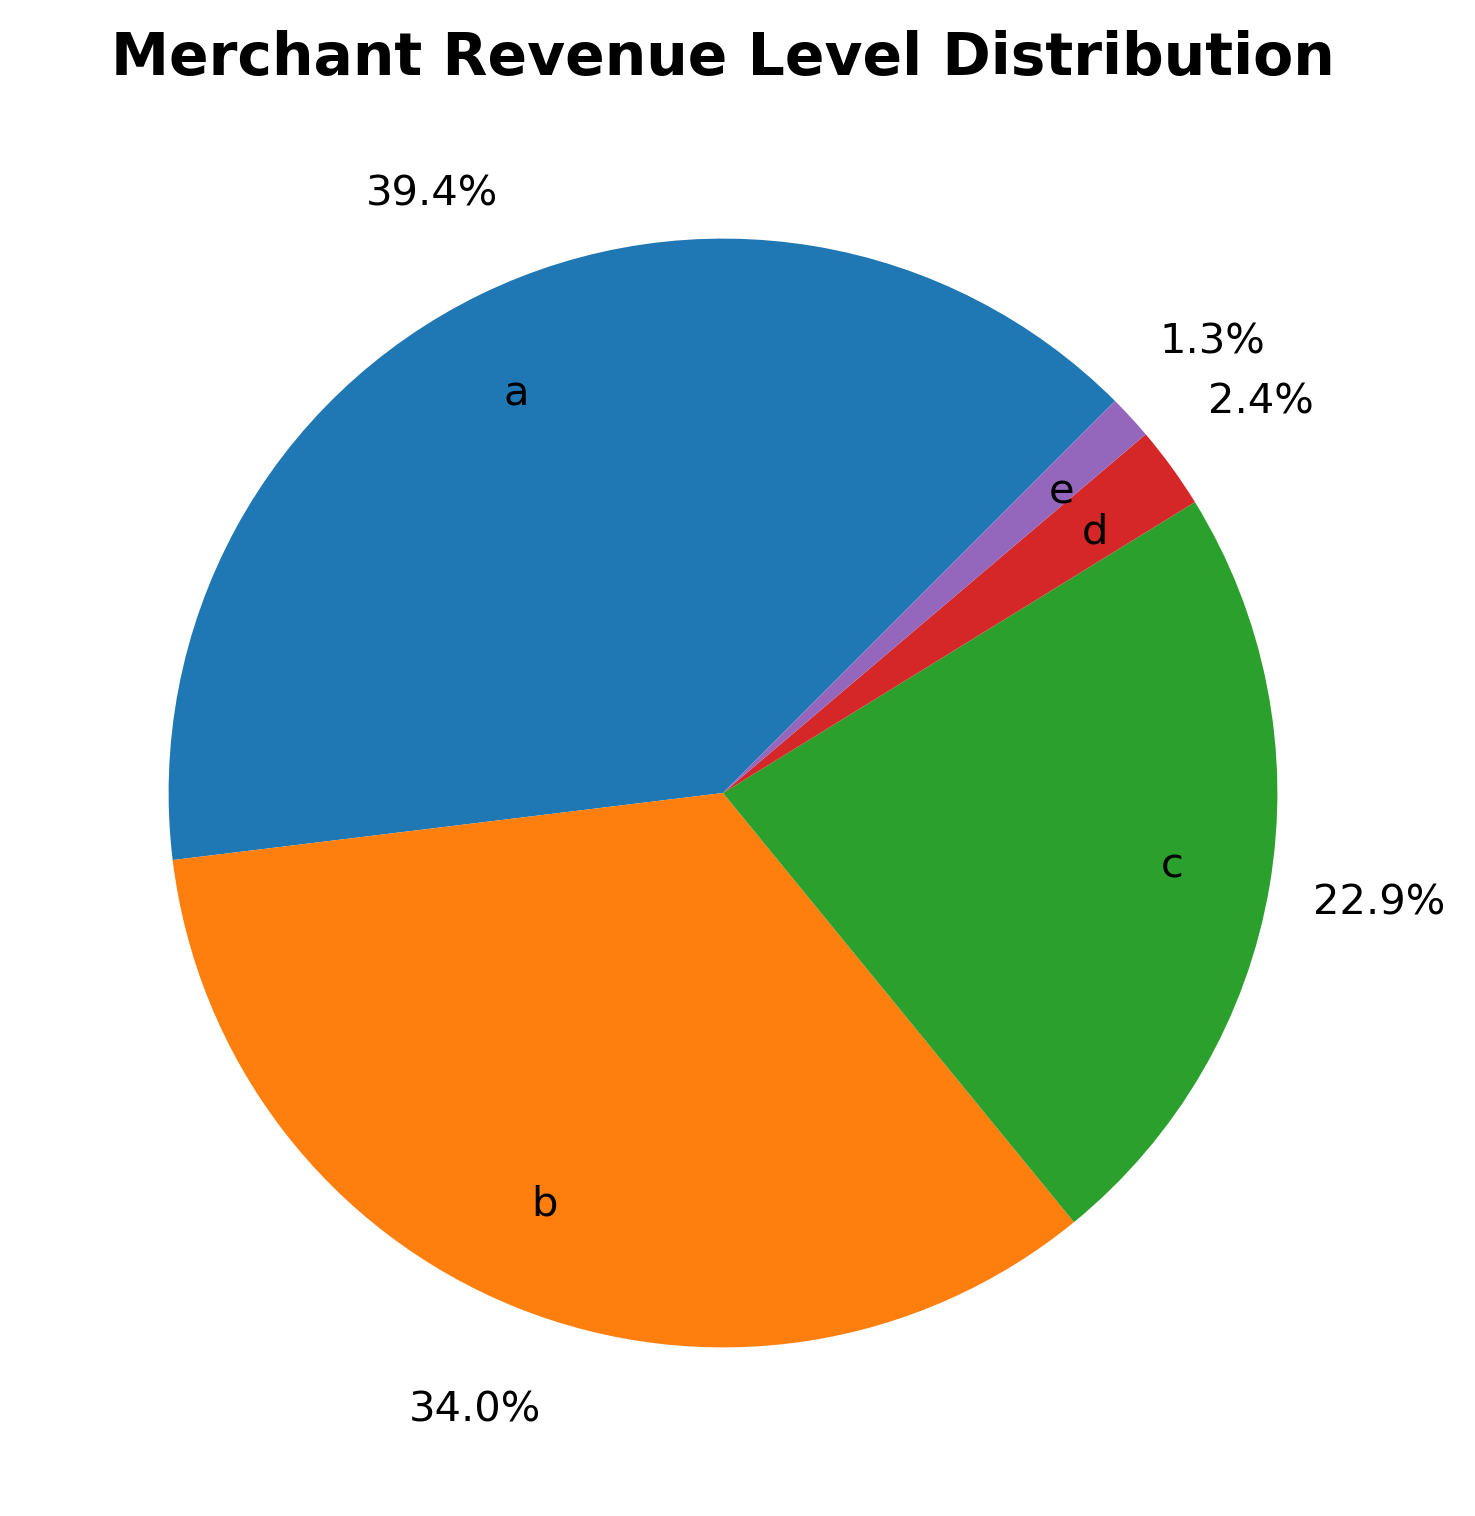

In [71]:
Image(filename='../plots/revenue_level_distribution.png', width=600, height=700)

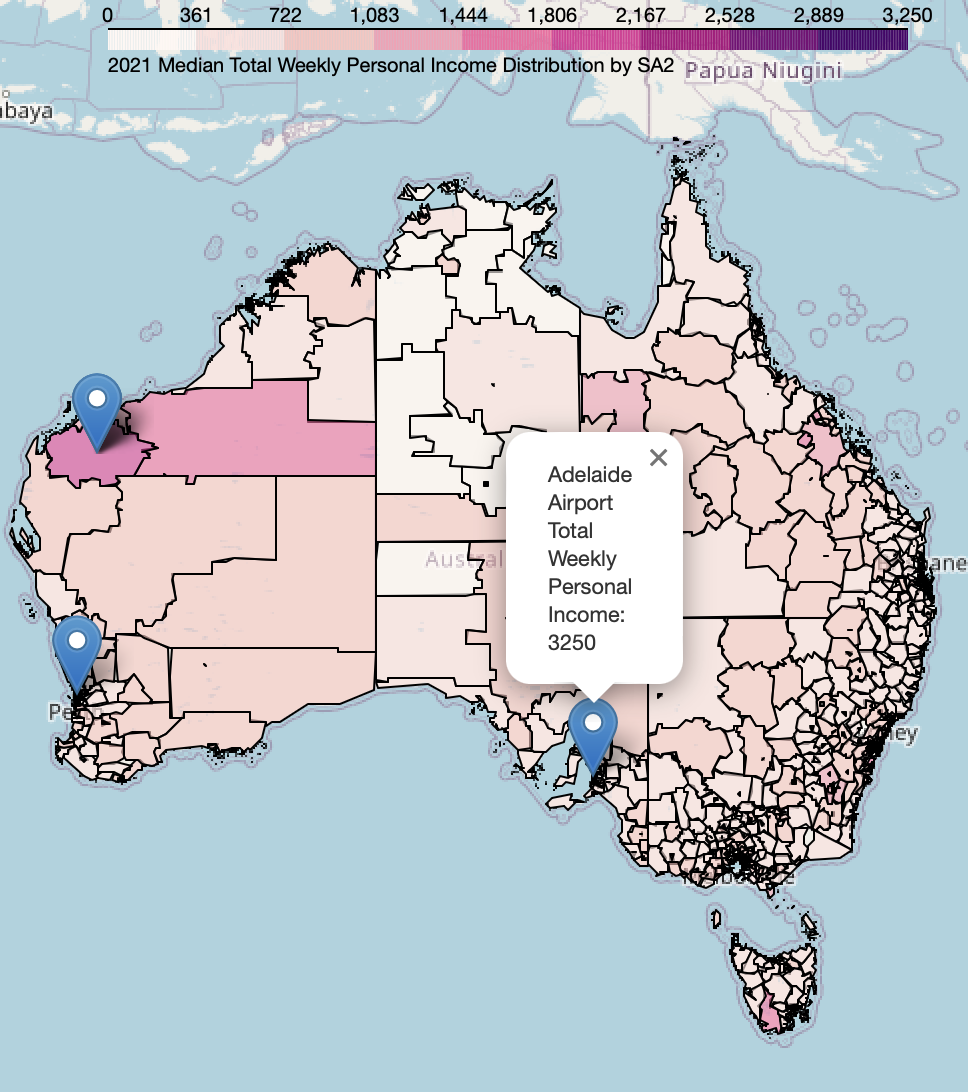

In [80]:
Image(filename='../plots/personal_income_map.png', width=900, height=1000)

The following plots show the aggregated results by selecting the top merchants.

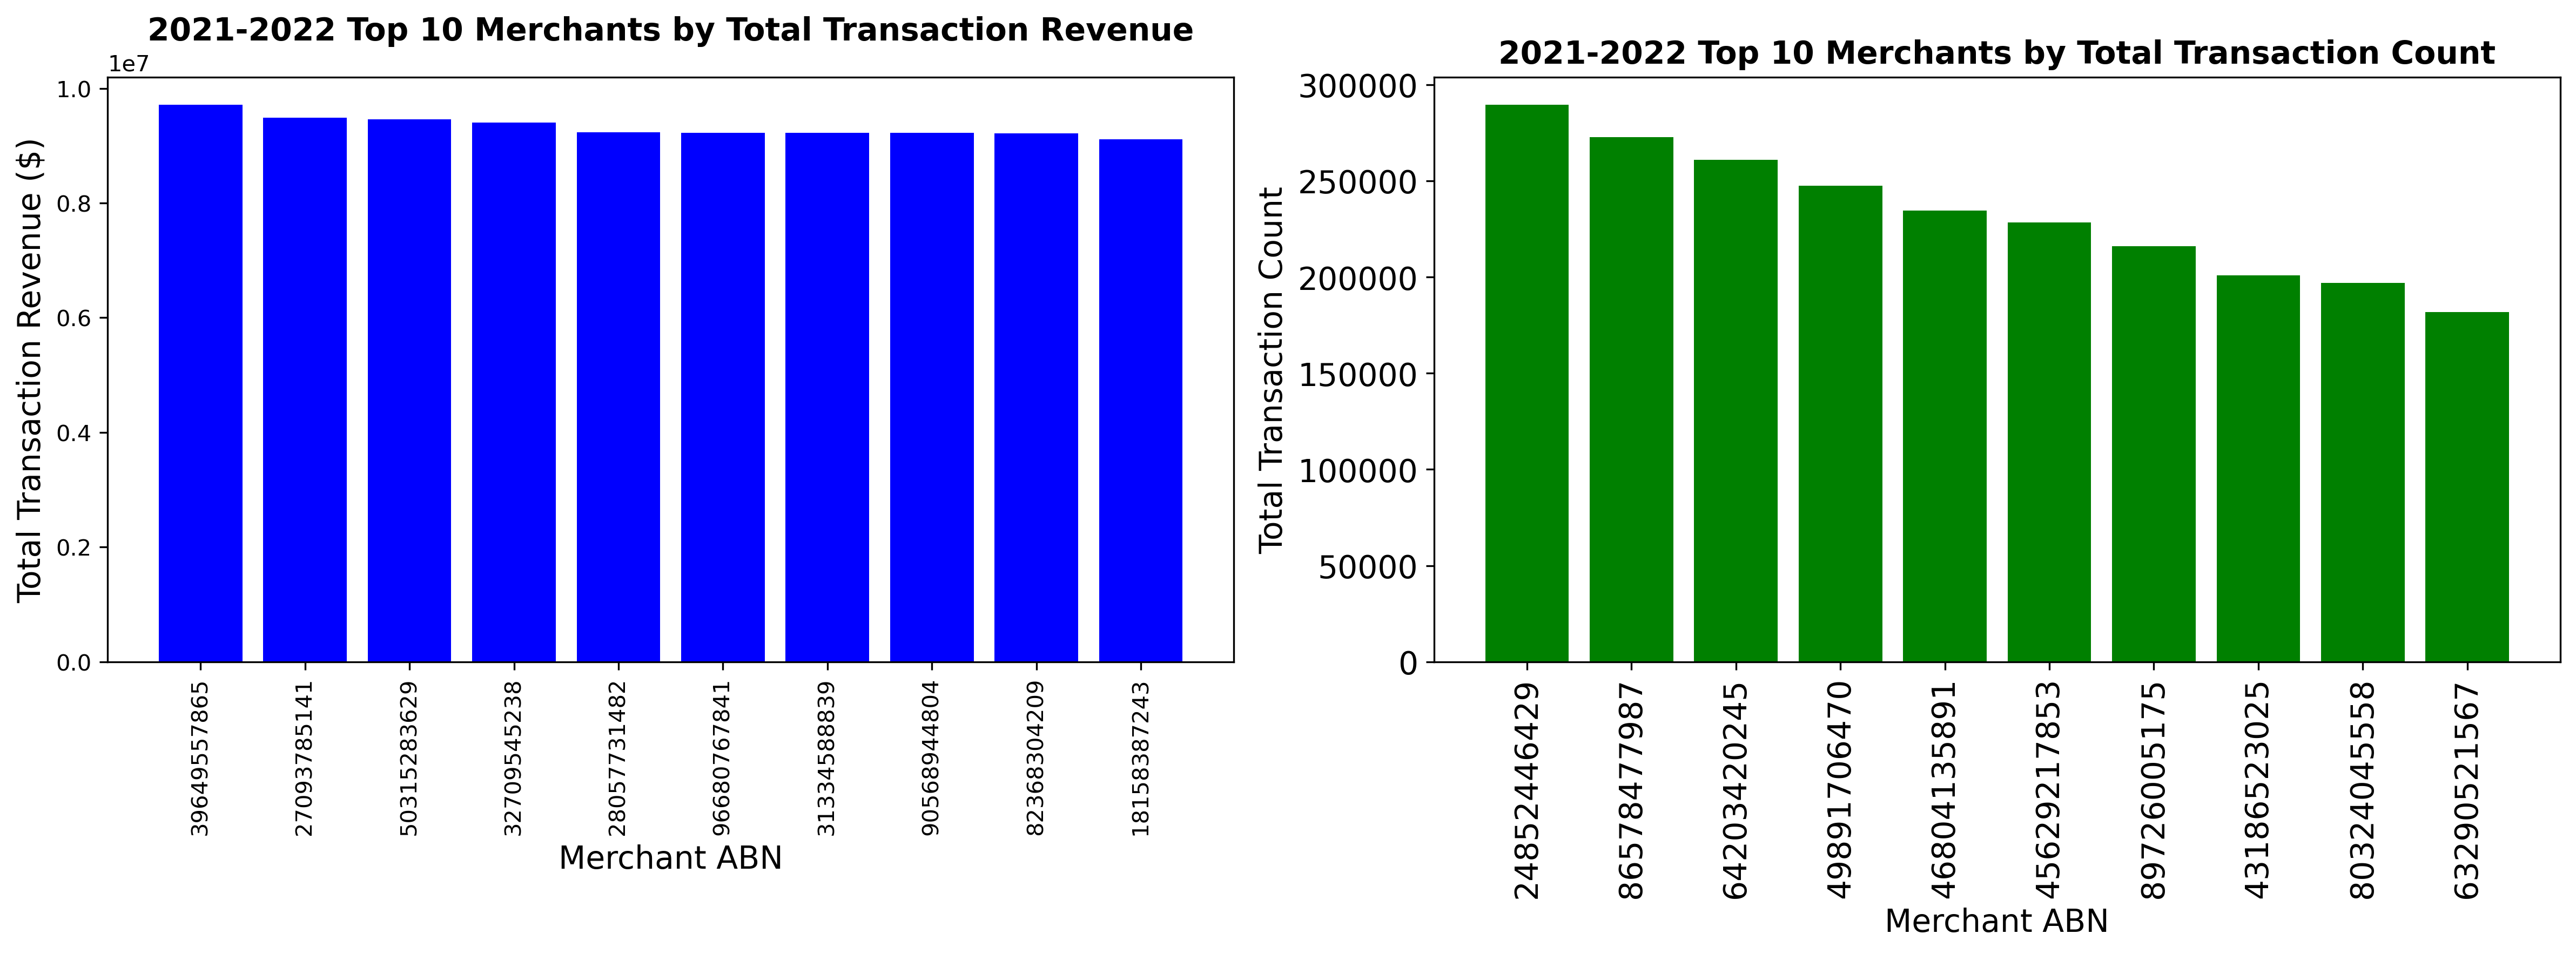

In [75]:
Image(filename='../plots/top10_merchants_toal_transaction_count_revenue.png', 
      width=900, height=1000)

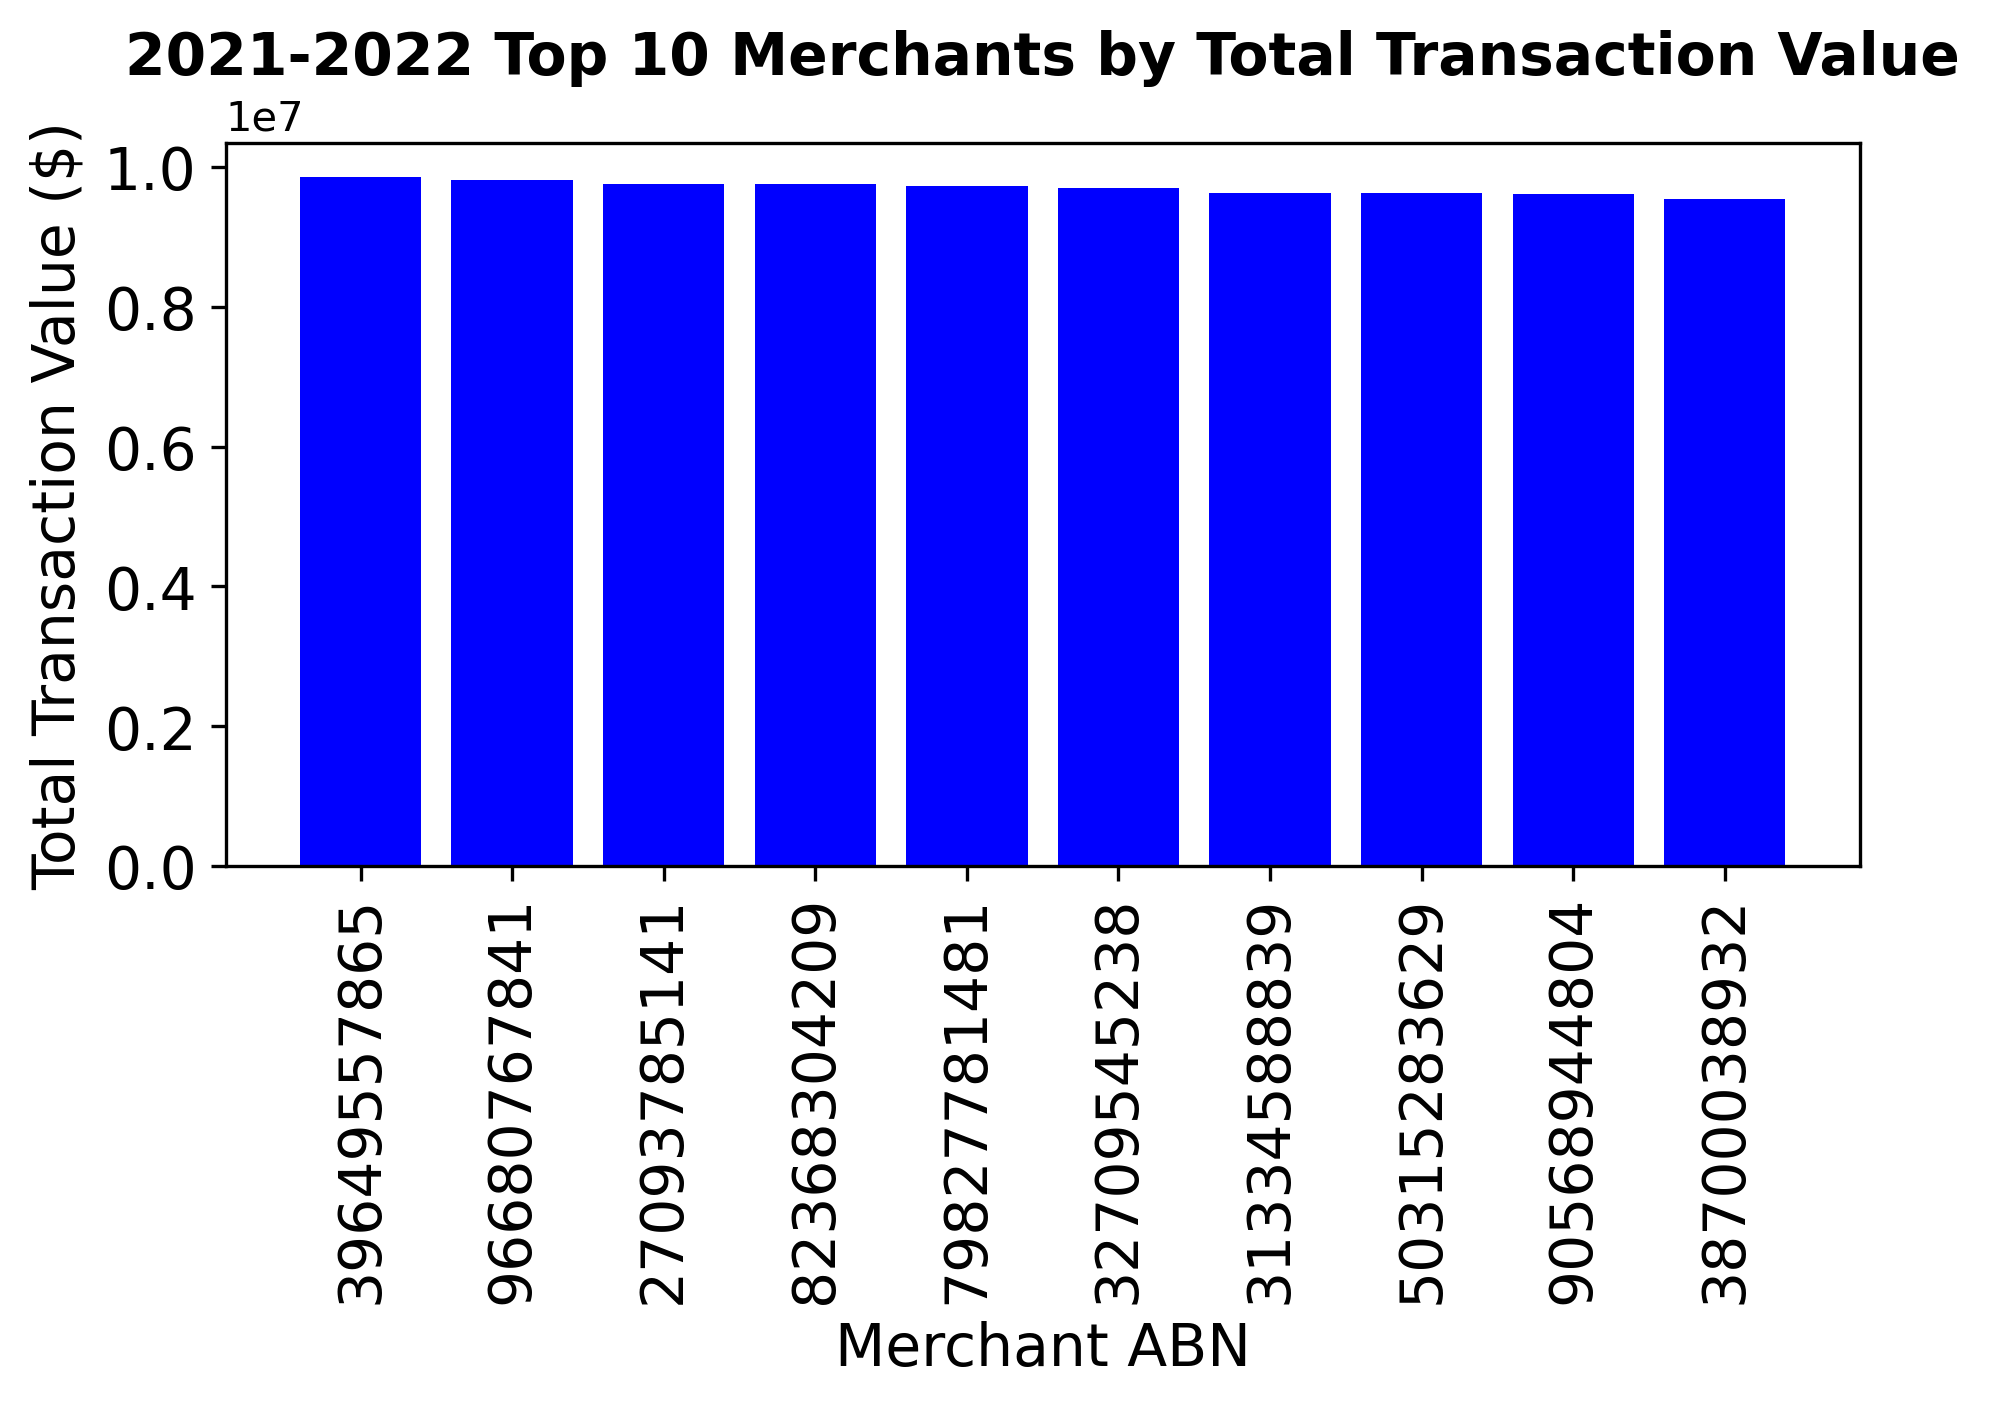

In [77]:
Image(filename='../plots/top10_merchants_toal_transaction_dollar.png', width=700, height=800)

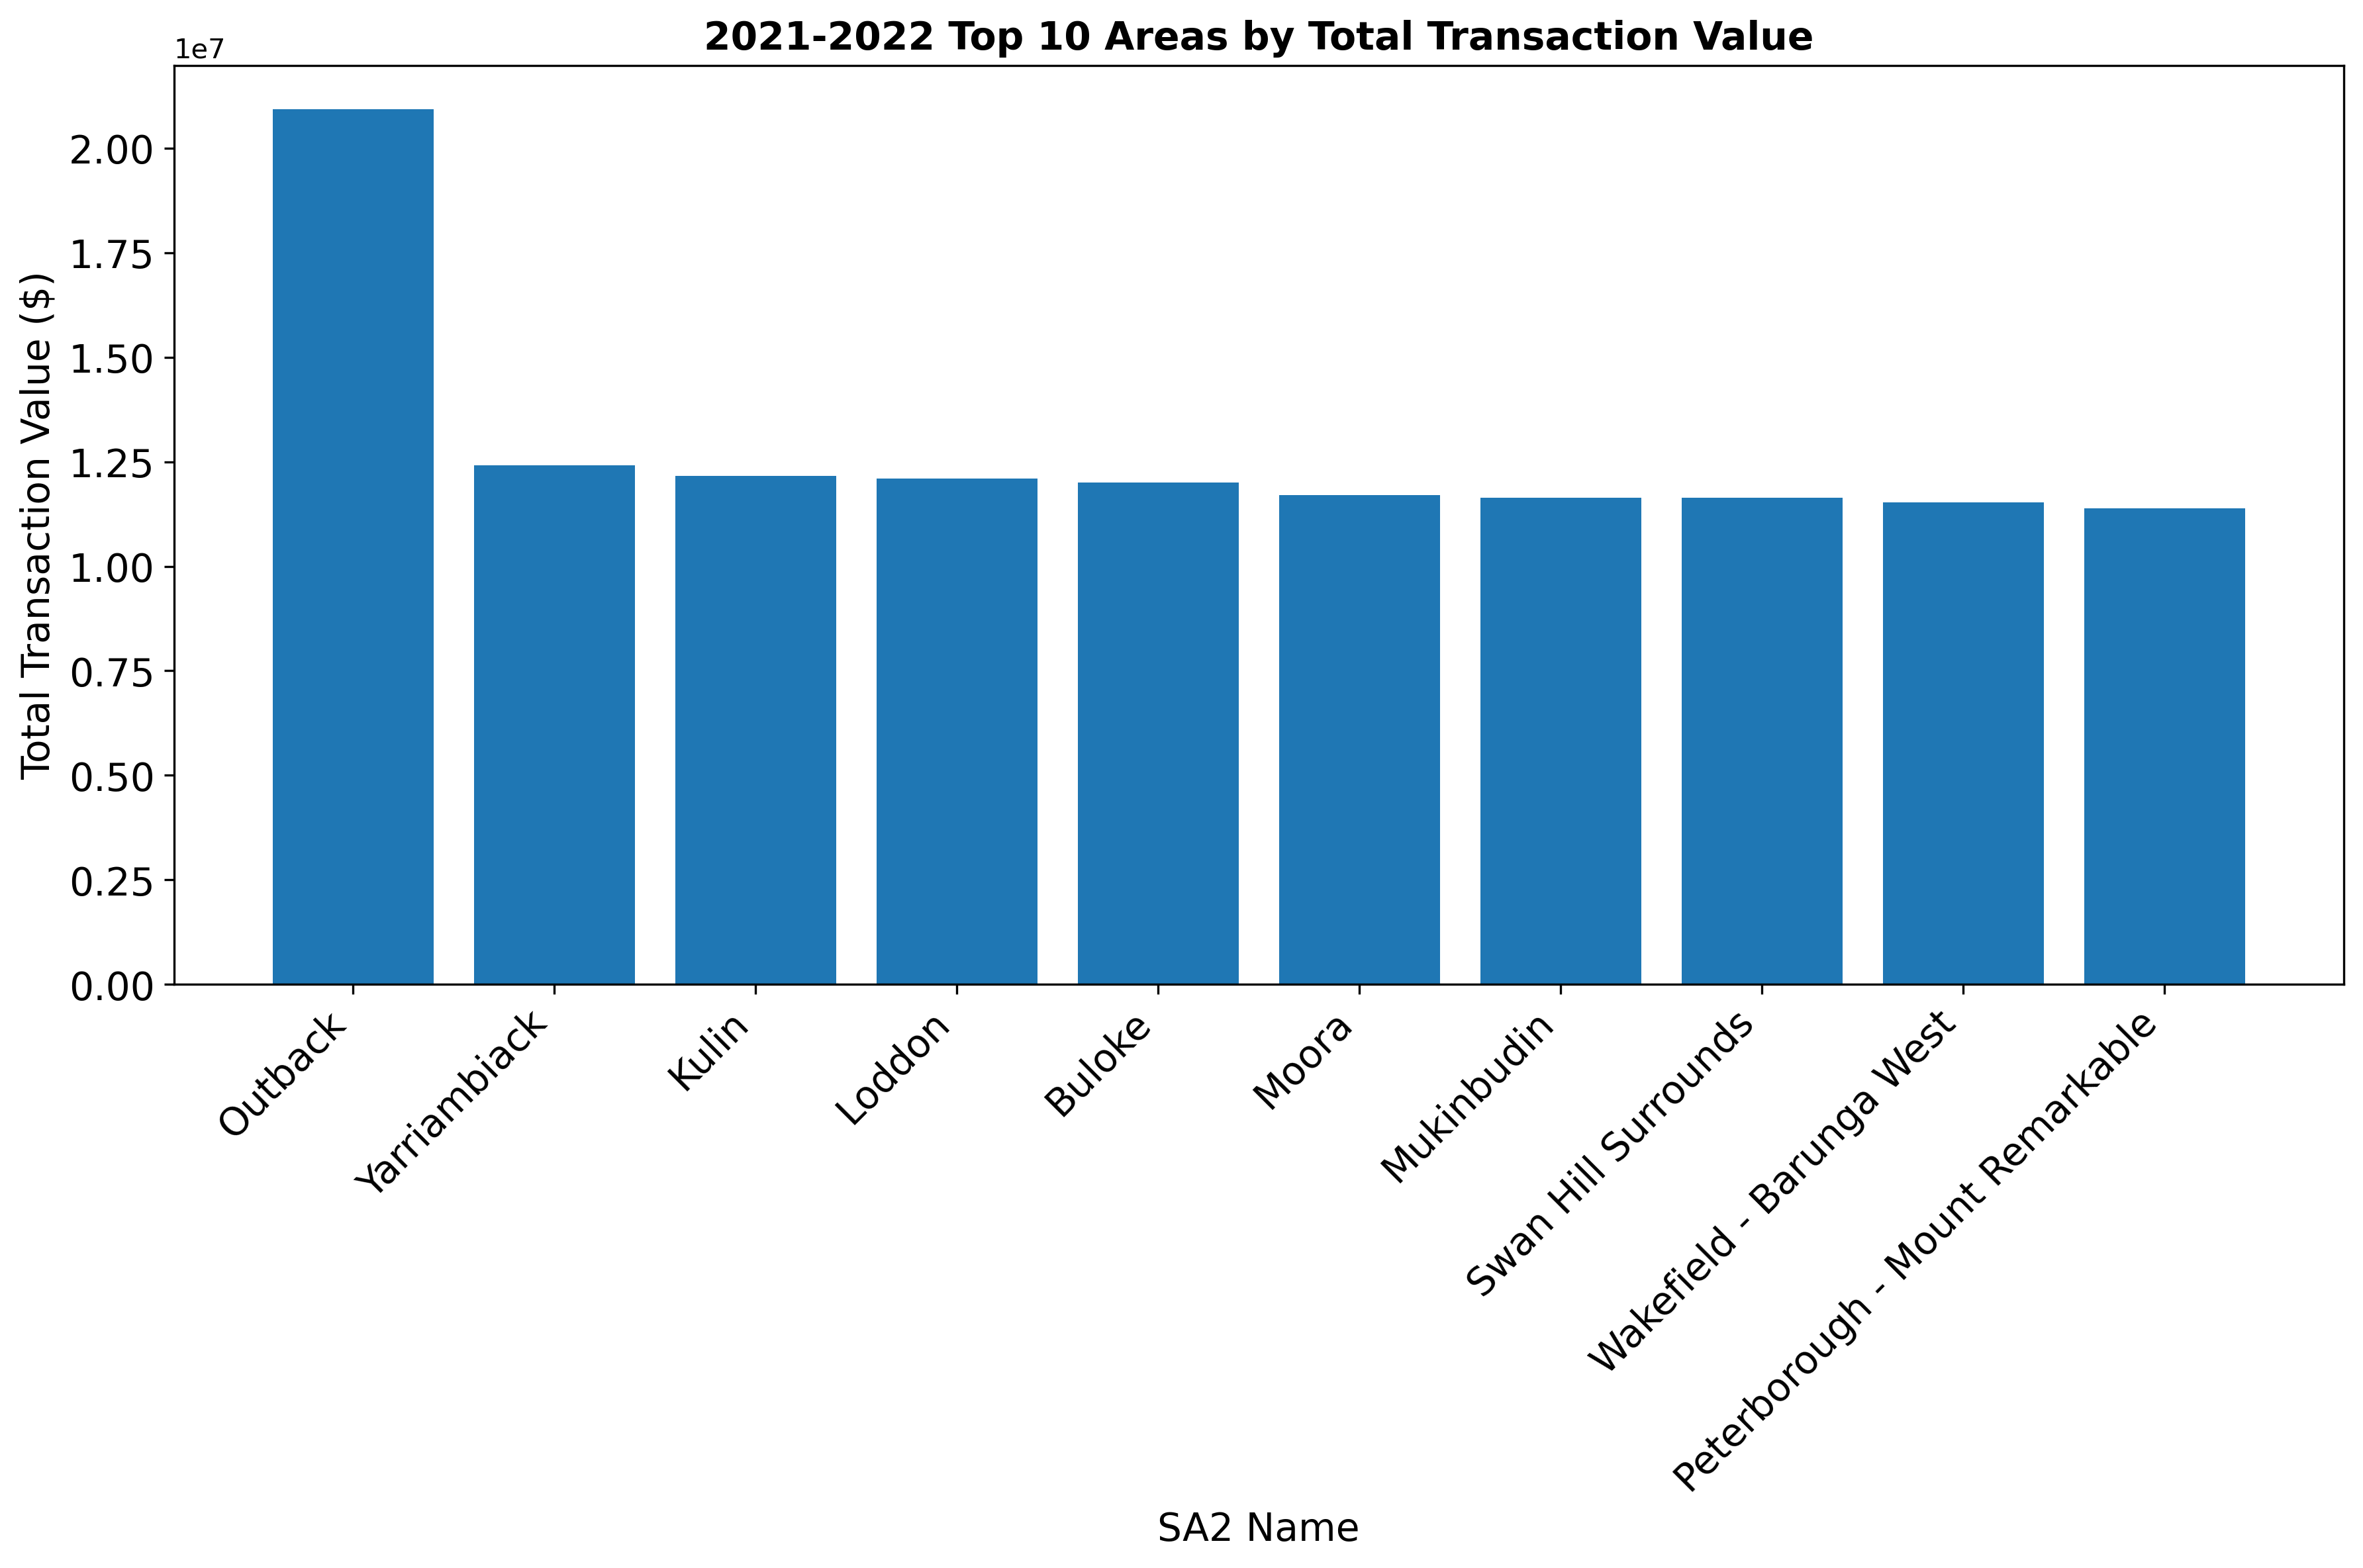

In [79]:
Image(filename='../plots/top10_SA2_by_consumer_dollar.png', width=900, height=1000)

# Limitations

For data availability and quality: 
- There are missing values in the 2022 SA2 dataset, particularly missing data from certain regions and features, which could limit the level of detail in geographical insights and reduce the robustness of location-based analyses.
- Limited access to detailed merchant and customer data restricts the ability to develop highly accurate predictive models (e.g. since the merchant ABN is not real, we cannot find more merchant related information). Incomplete data on transaction histories, consumer behavior, or merchant attributes can lead to a lack of precision in forecasting, identifying patterns, and detecting fraud trends.

For fraud detection models:
- It can suffer from both false positives and false negatives. False positives occur when merchants or customers are incorrectly flagged as fraudulent, which can lead to reputational damage or loss of business. On the other hand, false negatives occur when actual fraudulent activities go undetected, leaving the system vulnerable to financial loss.
- Misclassification of merchants based on inaccurate fraud detection may lead to improper restrictions on legitimate merchants, potentially affecting their business operations and reduce the credibility in the ranking system. This misclassification could also skew performance metrics, making it harder to identify truly high-risk merchants.